In [ ]:
import os

print("Top-level dataset folders:")
for d in os.listdir('/kaggle/input/datasets'):
    print(' -', d)

In [ ]:
import os

for top in ['xhlulu', 'organizations']:
    path = f'/kaggle/input/datasets/{top}'
    print(f"\n=== {top} ===")
    for d in os.listdir(path):
        print(' -', d)

In [ ]:
import os

for name, path in [
    ('CHEXPERT', '/kaggle/input/datasets/ashery/chexpert'),
    ('VINBIGDATA', '/kaggle/input/datasets/xhlulu/vinbigdata-chest-xray-png-512px-original-ratio'),
    ('NIH', '/kaggle/input/datasets/organizations/nih-chest-xrays'),
]:
    print(f"\n=== {name} ===")
    for item in os.listdir(path):
        print(' -', item)

In [ ]:
import os
print(os.listdir('/kaggle/input/datasets/organizations/nih-chest-xrays/data'))

In [ ]:
import os, pandas as pd

print("="*70, "\n1. CHEXPERT\n", "="*70, sep="")
chex_train = pd.read_csv('/kaggle/input/datasets/ashery/chexpert/train.csv')
print("Columns:", list(chex_train.columns))
print("Rows:", len(chex_train))
print(chex_train.head(3).to_string())
print("\nSample Path values (need patient_id extractable from here):")
print(chex_train['Path'].head(5).tolist())
pathology_cols = [c for c in chex_train.columns if c not in ['Path','Sex','Age','Frontal/Lateral','AP/PA']]
print("\nPathology columns:", pathology_cols)
print(f"\nUnique values in '{pathology_cols[0]}' (check for -1/0/1 uncertainty):")
print(chex_train[pathology_cols[0]].unique())

print("\n" + "="*70 + "\n2. VINBIGDATA (checking if labels actually exist)\n" + "="*70)
vinbig_meta = pd.read_csv('/kaggle/input/datasets/xhlulu/vinbigdata-chest-xray-png-512px-original-ratio/train_meta.csv')
print("train_meta.csv columns:", list(vinbig_meta.columns))
print("Rows:", len(vinbig_meta))
print(vinbig_meta.head(3).to_string())

print("\n" + "="*70 + "\n3. NIH CHEST X-RAYS\n" + "="*70)
nih_data = pd.read_csv('/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv')
print("Columns:", list(nih_data.columns))
print("Rows:", len(nih_data))
print(nih_data.head(3).to_string())
print("\nUnique Patient IDs vs total images (leakage check groundwork):")
print("Total images:", len(nih_data), "| Unique patients:", nih_data['Patient ID'].nunique())
print("\nSample Finding Labels (raw pathology strings):")
print(nih_data['Finding Labels'].value_counts().head(10))

In [ ]:
import os
for base in ['/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection',
             '/kaggle/input/vinbigdata-chest-xray-abnormalities-detection']:
    print(base, '->', os.path.exists(base))
    if os.path.exists(base):
        print(os.listdir(base))


In [ ]:
import pandas as pd

# Real labels from the official competition
vinbig_labels = pd.read_csv('/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train.csv')
print("Competition train.csv columns:", list(vinbig_labels.columns))
print("Rows:", len(vinbig_labels))
print(vinbig_labels.head(5).to_string())
print("\nUnique image_ids in competition labels:", vinbig_labels['image_id'].nunique())
print("\nClass names present:")
print(vinbig_labels['class_name'].value_counts())

# Compare against the resized image dataset's meta file we already checked
vinbig_meta = pd.read_csv('/kaggle/input/datasets/xhlulu/vinbigdata-chest-xray-png-512px-original-ratio/train_meta.csv')
print("\n\nOverlap check between the two datasets:")
label_ids = set(vinbig_labels['image_id'])
meta_ids = set(vinbig_meta['image_id'])
print("IDs in competition labels:", len(label_ids))
print("IDs in resized image meta:", len(meta_ids))
print("IDs in BOTH (matchable):", len(label_ids & meta_ids))

In [ ]:
import pandas as pd

vinbig_labels = pd.read_csv('/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train.csv')

# Check 1: does image_id ever repeat beyond the known multi-radiologist pattern?
# (we already know No Finding appears twice for 2 different images/radiologists,
# this checks total row count vs unique image count)
print("Total rows:", len(vinbig_labels))
print("Unique image_ids:", vinbig_labels['image_id'].nunique())
print("Avg rows per image (expect >1 due to multi-radiologist + multi-finding):",
      round(len(vinbig_labels) / vinbig_labels['image_id'].nunique(), 2))

# Check 2: any column that could hint at patient identity beyond image_id?
print("\nAll columns again for a fresh look:", list(vinbig_labels.columns))

# Check 3: look for a metadata file elsewhere in the competition download
# that might carry patient or study level info (some competitions ship a
# separate DICOM metadata csv even when images are pre-converted to PNG)
import os
comp_root = '/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection'
for f in os.listdir(comp_root):
    print(f)

# Check 4: same for the resized PNG dataset, in case xhlulu kept extra metadata
resized_root = '/kaggle/input/datasets/xhlulu/vinbigdata-chest-xray-png-512px-original-ratio'
for f in os.listdir(resized_root):
    print(f)

In [ ]:
import os

paths = {
    'CheXpert train CSV': '/kaggle/input/datasets/ashery/chexpert/train.csv',
    'CheXpert dir': '/kaggle/input/datasets/ashery/chexpert/',
    'NIH data CSV': '/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv',
    'NIH dir': '/kaggle/input/datasets/organizations/nih-chest-xrays/data/',
    'VinBig train CSV': '/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train.csv',
    'VinBig PNG dir': '/kaggle/input/datasets/xhlulu/vinbigdata-chest-xray-png-512px-original-ratio/',
}
for name, p in paths.items():
    print(f"{'OK ' if os.path.exists(p) else 'MISSING '} {name}: {p}")

In [ ]:
import pandas as pd
chex = pd.read_csv('/kaggle/input/datasets/ashery/chexpert/train.csv')  # fix path per V1
print("Shape:", chex.shape)
print("\nColumns:\n", list(chex.columns))
print("\nPath column sample:\n", chex['Path'].head(3).tolist())
print("\nNo Finding value counts (expect 1.0 and NaN, NO -1):")
print(chex['No Finding'].value_counts(dropna=False))

In [ ]:
chex['label'] = (chex['No Finding'] != 1.0).astype(int)  # 1 = pathology, 0 = no finding
print("Binary label distribution:")
print(chex['label'].value_counts())
print("Pathology fraction:", round(chex['label'].mean(), 4))

chex['patient_id'] = chex['Path'].str.extract(r'(patient\d+)')
print("\nUnique patients:", chex['patient_id'].nunique())
print("Images per patient (mean):", round(len(chex) / chex['patient_id'].nunique(), 2))
print("Any Path where patient_id failed to extract:", chex['patient_id'].isna().sum())

In [ ]:
nih = pd.read_csv('/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv')
print("Shape:", nih.shape)
print("Columns:\n", list(nih.columns))
print("\nFinding Labels sample:\n", nih['Finding Labels'].head(5).tolist())
nih['label'] = (nih['Finding Labels'] != 'No Finding').astype(int)
print("\nBinary distribution:")
print(nih['label'].value_counts())
print("Pathology fraction:", round(nih['label'].mean(), 4))
print("\nUnique patients:", nih['Patient ID'].nunique())

In [ ]:
vin = pd.read_csv('/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train.csv')
print("Shape (raw rows, expect ~68K):", vin.shape)
print("Columns:\n", list(vin.columns))
print("\nUnique image_ids (expect 15000):", vin['image_id'].nunique())
print("\nclass_id / class_name mapping:")
print(vin[['class_id','class_name']].drop_duplicates().sort_values('class_id').to_string(index=False))

# collapse: image is normal only if ALL its rows are "No finding" (class_id 14)
img_findings = vin.groupby('image_id')['class_id'].apply(lambda s: set(s))
def label_img(finding_set):
    return 0 if finding_set == {14} else 1  # only-No-finding = 0, any real finding = 1
vin_labels = img_findings.apply(label_img)
print("\nCollapsed binary distribution (per unique image):")
print(vin_labels.value_counts())
print("Pathology fraction:", round(vin_labels.mean(), 4))
print("Total unique images after collapse:", len(vin_labels))

In [ ]:
png_dir = '/kaggle/input/datasets/xhlulu/vinbigdata-chest-xray-png-512px-original-ratio/train'  # confirm subdir in V1
sample_ids = vin_labels.index[:5].tolist()
for iid in sample_ids:
    p = os.path.join(png_dir, iid + '.png')
    print(f"{'OK ' if os.path.exists(p) else 'MISSING '} {iid}.png")

In [ ]:
# ===== CELL 0a: SEED + DETERMINISM (must be first executable cell) =====
import os, random
import numpy as np
import tensorflow as tf
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(f"Seed {SEED} set, TF {tf.__version__}")   # expect TF 2.19.0

In [ ]:
# ===== CELL 0a-fix: PIN TF TO 2.19.0 (Kaggle image drifted to 2.20.0) =====
!pip install -q tensorflow==2.19.0
print("Installed. RESTART THE KERNEL now (Kaggle: Run > Restart session), then re-run Cell 0a from the top.")

In [ ]:
# ===== DIAGNOSTIC: disk version vs any cached import =====
import sys
print("tensorflow already in sys.modules:", "tensorflow" in sys.modules)
!pip show tensorflow | grep -i version

In [ ]:
# ===== RUN THIS FIRST, IMMEDIATELY AFTER RESTART, BEFORE ANY OTHER CELL =====
!pip install -q tensorflow==2.19.0
import tensorflow as tf
print("TF version now:", tf.__version__)   # expect 2.19.0

In [ ]:
# ===== CELL 0a: SEED + DETERMINISM (must be first executable cell) =====
import os, random
import numpy as np
import tensorflow as tf
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(f"Seed {SEED} set, TF {tf.__version__}")   # expect TF 2.19.0

In [ ]:
# ===== CELL 0b: IMPORTS =====
import pandas as pd
import glob
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as res_pre
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, MaxPooling2D,
                                      Dropout, GlobalAveragePooling2D, Dense)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
print("Imports ready")

In [ ]:
# ---------- PATHS (all confirmed to exist, cell V1) ----------
CHEX_DIR      = '/kaggle/input/datasets/ashery/chexpert/'
CHEX_CSV      = '/kaggle/input/datasets/ashery/chexpert/train.csv'
# CheXpert Path column is RELATIVE and already starts with 'CheXpert-v1.0-small/...', prepend CHEX_DIR

NIH_DIR       = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/'
NIH_CSV       = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv'
# NIH image files live in subfolders; Stage 1 builds a recursive filename->path map and gates on it

VINBIG_CSV    = '/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train.csv'
VINBIG_PNG    = '/kaggle/input/datasets/xhlulu/vinbigdata-chest-xray-png-512px-original-ratio/train/'
# VinBig images: VINBIG_PNG + image_id + '.png', confirmed joining on image_id (cell V6)

WEIGHTS_DIR   = '/kaggle/input/datasets/ab0y04/all-best-models/'
WORK_DIR      = '/kaggle/working/'

# ---------- CLASSES ----------
FINAL_CLASSES = ['no_finding', 'pathology']    # index 0 = no_finding, 1 = pathology
NUM_CLASSES   = 2

# ---------- IMAGE / BATCH ----------
IMG_SIZE   = 224
BATCH_SIZE = 32

# ---------- SEED ----------
SEED          = 42
SUBSAMPLE_SEED = 42     # locked: the 15k-per-source draw depends on this
CV_SEEDS      = [42, 123, 456, 789, 1024]

# ---------- SUBSAMPLE (Option A, natural prevalence, VinBig floor) ----------
TARGET_PER_SOURCE = 15000    # VinBigData's size is the binding floor

# ---------- TRAINING (identical to skin) ----------
PHASE1_EPOCHS = 10        # head only, backbone frozen
PHASE1_LR     = 1e-3
PHASE2_LR     = 1e-5      # full fine-tune
CUSTOM_LR     = 1e-3      # custom CNN, from scratch
EARLYSTOP_PAT = 7         # monitor val_accuracy, restore_best_weights=True
MONITOR       = 'val_accuracy'

# ---------- AUGMENTATION (train only). Mirrors skin exactly for cross-task consistency. vertical_flip OFF ----------
AUG = dict(rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
           horizontal_flip=True, zoom_range=0.1)
# Note (D-chest-2): horizontal_flip retained despite cardiac asymmetry, because the task is binary
# presence-detection and horizontal flip is standard in CXR literature. Reversible by explicit choice.

# ---------- WEIGHT FILE NAMES (chest-prefixed) ----------
W_CUSTOM = 'best_custom_cnn_chest.keras'
W_EFF    = 'best_efficientnet_chest.keras'
W_MOB    = 'best_mobilenet_chest.keras'
W_RES    = 'best_resnet50_chest.keras'

print("Config loaded.")

In [ ]:
# ===== CELL 1a: CHEXPERT, binary label + patient id + resolved image path =====
chex = pd.read_csv(CHEX_CSV)
chex['label'] = np.where(chex['No Finding'] == 1.0, 'no_finding', 'pathology')
chex['patient_id'] = chex['Path'].str.extract(r'(patient\d+)')
chex['image_path'] = CHEX_DIR + chex['Path']          # relative Path already includes CheXpert-v1.0-small/
chex['source'] = 'chex'
assert chex['patient_id'].isna().sum() == 0, "CheXpert patient_id extraction failed on some rows"

# HARD GATE: confirm the resolved image paths actually exist (sample 200, must be 100% present)
_sample = chex['image_path'].sample(200, random_state=SEED)
_present = _sample.apply(os.path.exists).sum()
print(f"CheXpert path check: {_present}/200 present")
assert _present == 200, "CheXpert image paths do not resolve, fix CHEX_DIR + Path join before proceeding"

print("CheXpert rows:", len(chex), "| pathology frac:", round((chex['label']=='pathology').mean(), 4),
      "| patients:", chex['patient_id'].nunique())   # expect 223414, 0.8998, 64540

In [ ]:
# ===== CELL 1a-fix: CORRECTED CHEXPERT PATH JOIN =====
# DEVIATION FROM MANUAL, FLAGGED: this specific Kaggle mirror (ashery/chexpert) strips the
# 'CheXpert-v1.0-small/' prefix from the on-disk folder structure. The CSV's Path column still
# includes it. Confirmed live via os.walk (train/valid sit directly under CHEX_DIR). Strip the
# prefix before joining, rather than prepending CHEX_DIR to the raw Path as originally written.
chex['image_path'] = CHEX_DIR + chex['Path'].str.replace('CheXpert-v1.0-small/', '', regex=False)

_sample = chex['image_path'].sample(200, random_state=SEED)
_present = _sample.apply(os.path.exists).sum()
print(f"CheXpert path check (corrected): {_present}/200 present")
assert _present == 200, "CheXpert image paths still do not resolve, needs further inspection"

print("CheXpert rows:", len(chex), "| pathology frac:", round((chex['label']=='pathology').mean(), 4),
      "| patients:", chex['patient_id'].nunique())

In [ ]:
# ===== CELL 1b: NIH, binary label + patient id + recursive image-path map =====
nih = pd.read_csv(NIH_CSV)
nih['label'] = np.where(nih['Finding Labels'] == 'No Finding', 'no_finding', 'pathology')
nih['patient_id'] = nih['Patient ID'].astype(str)
nih['source'] = 'nih'

# NIH images live in subfolders; build a filename -> full path map ONCE (recursive glob)
print("Globbing NIH images (one-time, may take a minute)...")
nih_files = glob.glob(os.path.join(NIH_DIR, '**', '*.png'), recursive=True)
nih_map = {os.path.basename(p): p for p in nih_files}
print(f"NIH image files found on disk: {len(nih_map)}")   # expect ~112120
nih['image_path'] = nih['Image Index'].map(nih_map)

# HARD GATE: every labeled row must resolve to a file
_unresolved = nih['image_path'].isna().sum()
print(f"NIH unresolved image paths: {_unresolved}")
assert _unresolved == 0, "NIH images did not all resolve, inspect NIH_DIR subfolder structure before proceeding"

print("NIH rows:", len(nih), "| pathology frac:", round((nih['label']=='pathology').mean(), 4),
      "| patients:", nih['patient_id'].nunique())     # expect 112120, 0.4616, 30805

In [ ]:
# ===== CELL 1c: VINBIGDATA, collapse radiologist rows to one binary label per image =====
vin_raw = pd.read_csv(VINBIG_CSV)
# collapse: an image is no_finding only if its ONLY finding is class_id 14 ("No finding"); any real finding -> pathology
img_findings = vin_raw.groupby('image_id')['class_id'].apply(lambda s: set(s))
vin = pd.DataFrame({'image_id': img_findings.index})
vin['label'] = img_findings.apply(lambda fs: 'no_finding' if fs == {14} else 'pathology').values
vin['image_path'] = VINBIG_PNG + vin['image_id'] + '.png'
vin['source'] = 'vinbig'
vin['patient_id'] = None    # no patient identifier exists, disclosed limitation, split at image level

# HARD GATE: sample 200 image paths, must all exist
_sample = vin['image_path'].sample(200, random_state=SEED)
_present = _sample.apply(os.path.exists).sum()
print(f"VinBig path check: {_present}/200 present")
assert _present == 200, "VinBig image paths do not resolve, check VINBIG_PNG subdir before proceeding"

print("VinBig unique images:", len(vin), "| pathology frac:", round((vin['label']=='pathology').mean(), 4))
# expect 15000, 0.2929

In [ ]:
# ===== CELL 1d: SUBSAMPLE to 15k per source (Option A, own prevalence, patient-level for chex/nih) =====

def subsample_by_patient(df, target_n, seed=SUBSAMPLE_SEED):
    """Randomly select whole patients until image count reaches ~target_n.
    Preserves prevalence in expectation (random patient draw). Never splits a patient."""
    pats = df['patient_id'].drop_duplicates().sample(frac=1.0, random_state=seed).tolist()
    chosen, count = [], 0
    for p in pats:
        n = (df['patient_id'] == p).sum()
        if count + n > target_n and count >= target_n * 0.98:
            break                      # close enough, do not overshoot
        chosen.append(p); count += n
        if count >= target_n:
            break
    return df[df['patient_id'].isin(chosen)].reset_index(drop=True)

chex_s = subsample_by_patient(chex, TARGET_PER_SOURCE)
nih_s  = subsample_by_patient(nih,  TARGET_PER_SOURCE)
vin_s  = vin.copy()                    # VinBig is the floor, use all 15,000

# CLASS-DISTRIBUTION-MATCHES-PARENT GATE (this is what makes subsampling defensible in the paper)
for name, full, sub in [('CheXpert', chex, chex_s), ('NIH', nih, nih_s), ('VinBig', vin, vin_s)]:
    pf_full = (full['label']=='pathology').mean()
    pf_sub  = (sub['label']=='pathology').mean()
    print(f"{name}: parent pathology {pf_full:.4f} | subsample pathology {pf_sub:.4f} "
          f"| n={len(sub)} | drift {abs(pf_full-pf_sub):.4f}")
    assert abs(pf_full - pf_sub) < 0.03, f"{name} subsample prevalence drifted >3pp from parent"

cols = ['image_path', 'label', 'source', 'patient_id']
master_df = pd.concat([chex_s[cols], nih_s[cols], vin_s[cols]], ignore_index=True)
print(f"\nPooled subsample: {len(master_df):,}")
print("Per-source / per-label:\n", pd.crosstab(master_df['source'], master_df['label']))

In [ ]:
# ===== CELL 2a: SAFE SPLIT WRAPPER + PER-SOURCE SPLIT =====

def safe_split(df, label_col, test_size, rs, tag=""):
    """Stratified split; fall back to unstratified for this step only if a class is too small."""
    try:
        return train_test_split(df, test_size=test_size, stratify=df[label_col], random_state=rs)
    except ValueError as e:
        print(f"WARNING [{tag}]: stratified split failed. Falling back to unstratified.")
        print(f"  sklearn error: {e}")
        return train_test_split(df, test_size=test_size, random_state=rs)

def split_patient_level(df, rs=SEED, tag=""):
    """Assign whole patients to train/val/test (70/15/15), stratified by the patient's majority label."""
    pg = df.groupby('patient_id')['label'].agg(lambda s: s.value_counts().index[0]).reset_index()
    p_tr, p_tmp = safe_split(pg, 'label', 0.30, rs, tag=f"{tag} first split")
    p_va, p_te  = safe_split(p_tmp, 'label', 0.50, rs, tag=f"{tag} second split")
    pick = lambda ids: df[df['patient_id'].isin(ids['patient_id'])]
    return (pick(p_tr), pick(p_va), pick(p_te),
            set(p_tr['patient_id']), set(p_va['patient_id']), set(p_te['patient_id']))

def split_image_level(df, rs=SEED, tag="VinBig"):
    """VinBig only: no patient key exists, split at image level, stratified by label."""
    tr, tmp = safe_split(df, 'label', 0.30, rs, tag=f"{tag} first split")
    va, te  = safe_split(tmp, 'label', 0.50, rs, tag=f"{tag} second split")
    return tr, va, te

# per-source splits
c_tr, c_va, c_te, cs_tr, cs_va, cs_te = split_patient_level(chex_s, tag="CheXpert")
n_tr, n_va, n_te, ns_tr, ns_va, ns_te = split_patient_level(nih_s,  tag="NIH")
v_tr, v_va, v_te = split_image_level(vin_s)

# leakage gates for the two patient-level sources
assert cs_tr.isdisjoint(cs_te) and cs_tr.isdisjoint(cs_va) and cs_va.isdisjoint(cs_te), "CHEXPERT PATIENT LEAKAGE"
assert ns_tr.isdisjoint(ns_te) and ns_tr.isdisjoint(ns_va) and ns_va.isdisjoint(ns_te), "NIH PATIENT LEAKAGE"
print("CheXpert patient-leakage check: PASS")
print("NIH patient-leakage check: PASS")

# pooled splits (concatenate per-source parts)
train_df = pd.concat([c_tr, n_tr, v_tr], ignore_index=True)
val_df   = pd.concat([c_va, n_va, v_va], ignore_index=True)
test_df  = pd.concat([c_te, n_te, v_te], ignore_index=True)

# persist splits (each source's per-split membership is needed for Stages 11 to 13)
for name, d in [('train',train_df),('val',val_df),('test',test_df)]:
    d.to_csv(f'/kaggle/working/chest_{name}_split.csv', index=False)
# also persist per-source splits for single-source stages
for src, parts in [('chex',(c_tr,c_va,c_te)), ('nih',(n_tr,n_va,n_te)), ('vinbig',(v_tr,v_va,v_te))]:
    for sp, d in zip(['train','val','test'], parts):
        d.to_csv(f'/kaggle/working/chest_{src}_{sp}.csv', index=False)

print(f"\nPooled Train {len(train_df):,} | Val {len(val_df):,} | Test {len(test_df):,}")
print("Test per-source/label:\n", pd.crosstab(test_df['source'], test_df['label']))

In [ ]:
# ===== CELL 2b: BALANCED CLASS WEIGHTS (from the pooled train set) =====
cls = np.array(FINAL_CLASSES)                          # ['no_finding','pathology']
cw  = compute_class_weight('balanced', classes=cls, y=train_df['label'])
CLASS_WEIGHT = {i: w for i, w in enumerate(cw)}        # index 0=no_finding, 1=pathology
print("class_weight:", {c: round(w,3) for c,w in zip(cls, cw)})

In [ ]:
# ===== CELL 2c: GENERATOR FACTORY (enforces per-model preprocessing structurally) =====
def make_gens(preprocess_fn, tr_df=None, va_df=None, te_df=None):
    """preprocess_fn=None -> custom CNN (rescale 1./255). Else pretrained (no rescale).
    Defaults to the pooled splits; pass source-specific frames for single-source stages."""
    tr_df = train_df if tr_df is None else tr_df
    va_df = val_df   if va_df is None else va_df
    te_df = test_df  if te_df is None else te_df
    if preprocess_fn is None:
        train_idg = ImageDataGenerator(rescale=1./255, **AUG)
        eval_idg  = ImageDataGenerator(rescale=1./255)
    else:
        train_idg = ImageDataGenerator(preprocessing_function=preprocess_fn, **AUG)
        eval_idg  = ImageDataGenerator(preprocessing_function=preprocess_fn)
    common = dict(x_col='image_path', y_col='label',
                  target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH_SIZE,
                  class_mode='categorical', classes=FINAL_CLASSES, color_mode='rgb')
    tr = train_idg.flow_from_dataframe(tr_df, shuffle=True,  seed=SEED, **common)
    va = eval_idg.flow_from_dataframe(va_df,  shuffle=False, **common)
    te = eval_idg.flow_from_dataframe(te_df,  shuffle=False, **common)
    return tr, va, te

_t,_v,_e = make_gens(None)
print(_e.class_indices)   # must be {'no_finding':0,'pathology':1}

In [ ]:
# ===== CELL 3a: CUSTOM CNN (3-block, from scratch) IDENTICAL to skin except num_classes=2 =====
def build_custom_cnn(num_classes=2, shape=(224,224,3)):
    m = Sequential([
        Input(shape=shape),
        Conv2D(32,3,padding='same',activation='relu'), BatchNormalization(),
        Conv2D(32,3,padding='same',activation='relu'), BatchNormalization(),
        MaxPooling2D(), Dropout(0.25),
        Conv2D(64,3,padding='same',activation='relu'), BatchNormalization(),
        Conv2D(64,3,padding='same',activation='relu'), BatchNormalization(),
        MaxPooling2D(), Dropout(0.25),
        Conv2D(128,3,padding='same',activation='relu'), BatchNormalization(),
        Conv2D(128,3,padding='same',activation='relu'), BatchNormalization(),
        MaxPooling2D(), Dropout(0.25),
        GlobalAveragePooling2D(),
        Dense(256,activation='relu'), Dropout(0.5),
        Dense(num_classes,activation='softmax')
    ])
    return m

# ===== CELL 3b: PRETRAINED BUILDER (backbone nested -> Grad-CAM friendly) =====
def build_pretrained(base_class, num_classes=2, shape=(224,224,3)):
    base = base_class(include_top=False, weights='imagenet', input_shape=shape)
    model = Sequential([
        base,
        GlobalAveragePooling2D(),
        Dense(256,activation='relu'),
        Dropout(0.3),
        Dense(num_classes,activation='softmax')
    ])
    return model, base

print(build_custom_cnn().count_params(), "custom params (record as chest canonical)")

In [ ]:
# ===== CHEST FULL REBUILD (new session): SEED + LEGACY KERAS FIX + IMPORTS + CONFIG =====
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'   # must be set before tensorflow is imported

import random
import numpy as np
import pandas as pd
import glob
import tensorflow as tf
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(f"Seed {SEED} set, TF {tf.__version__}, tf.keras module: {tf.keras.__name__}")

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as res_pre
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, MaxPooling2D,
                                      Dropout, GlobalAveragePooling2D, Dense)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
print("Imports ready")

# ---------- CONFIG ----------
CHEX_DIR      = '/kaggle/input/datasets/ashery/chexpert/'
CHEX_CSV      = '/kaggle/input/datasets/ashery/chexpert/train.csv'
NIH_DIR       = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/'
NIH_CSV       = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv'
VINBIG_CSV    = '/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train.csv'
VINBIG_PNG    = '/kaggle/input/datasets/xhlulu/vinbigdata-chest-xray-png-512px-original-ratio/train/'
WEIGHTS_DIR   = '/kaggle/input/datasets/ab0y04/all-best-models/'
WORK_DIR      = '/kaggle/working/'

FINAL_CLASSES = ['no_finding', 'pathology']
NUM_CLASSES   = 2
IMG_SIZE   = 224
BATCH_SIZE = 32
SUBSAMPLE_SEED = 42
CV_SEEDS      = [42, 123, 456, 789, 1024]
TARGET_PER_SOURCE = 15000
PHASE1_EPOCHS = 10
PHASE1_LR     = 1e-3
PHASE2_LR     = 1e-5
CUSTOM_LR     = 1e-3
EARLYSTOP_PAT = 7
MONITOR       = 'val_accuracy'
AUG = dict(rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
           horizontal_flip=True, zoom_range=0.1)
W_CUSTOM = 'best_custom_cnn_chest.keras'
W_EFF    = 'best_efficientnet_chest.keras'
W_MOB    = 'best_mobilenet_chest.keras'
W_RES    = 'best_resnet50_chest.keras'
print("Config loaded.")

In [ ]:
# ===== STAGE 1 REBUILD: CHEXPERT (path fix baked in) + NIH + VINBIG + SUBSAMPLE =====

# ---- CheXpert ----
chex = pd.read_csv(CHEX_CSV)
chex['label'] = np.where(chex['No Finding'] == 1.0, 'no_finding', 'pathology')
chex['patient_id'] = chex['Path'].str.extract(r'(patient\d+)')
# DEVIATION (disclosed): this Kaggle mirror strips 'CheXpert-v1.0-small/' from on-disk folders; CSV Path retains it.
chex['image_path'] = CHEX_DIR + chex['Path'].str.replace('CheXpert-v1.0-small/', '', regex=False)
chex['source'] = 'chex'
assert chex['patient_id'].isna().sum() == 0, "CheXpert patient_id extraction failed"
_sample = chex['image_path'].sample(200, random_state=SEED)
_present = _sample.apply(os.path.exists).sum()
print(f"CheXpert path check: {_present}/200 present")
assert _present == 200, "CheXpert path gate failed"
print("CheXpert rows:", len(chex), "| pathology frac:", round((chex['label']=='pathology').mean(),4),
      "| patients:", chex['patient_id'].nunique())

# ---- NIH ----
nih = pd.read_csv(NIH_CSV)
nih['label'] = np.where(nih['Finding Labels'] == 'No Finding', 'no_finding', 'pathology')
nih['patient_id'] = nih['Patient ID'].astype(str)
nih['source'] = 'nih'
print("Globbing NIH images...")
nih_files = glob.glob(os.path.join(NIH_DIR, '**', '*.png'), recursive=True)
nih_map = {os.path.basename(p): p for p in nih_files}
print(f"NIH files found: {len(nih_map)}")
nih['image_path'] = nih['Image Index'].map(nih_map)
_unresolved = nih['image_path'].isna().sum()
print(f"NIH unresolved: {_unresolved}")
assert _unresolved == 0, "NIH path gate failed"
print("NIH rows:", len(nih), "| pathology frac:", round((nih['label']=='pathology').mean(),4),
      "| patients:", nih['patient_id'].nunique())

# ---- VinBig ----
vin_raw = pd.read_csv(VINBIG_CSV)
img_findings = vin_raw.groupby('image_id')['class_id'].apply(lambda s: set(s))
vin = pd.DataFrame({'image_id': img_findings.index})
vin['label'] = img_findings.apply(lambda fs: 'no_finding' if fs == {14} else 'pathology').values
vin['image_path'] = VINBIG_PNG + vin['image_id'] + '.png'
vin['source'] = 'vinbig'
vin['patient_id'] = None
_sample = vin['image_path'].sample(200, random_state=SEED)
_present = _sample.apply(os.path.exists).sum()
print(f"VinBig path check: {_present}/200 present")
assert _present == 200, "VinBig path gate failed"
print("VinBig unique images:", len(vin), "| pathology frac:", round((vin['label']=='pathology').mean(),4))

# ---- Subsample (speed fix: precomputed sizes instead of rescanning full df per patient) ----
def subsample_by_patient(df, target_n, seed=SUBSAMPLE_SEED):
    pats = df['patient_id'].drop_duplicates().sample(frac=1.0, random_state=seed).tolist()
    sizes = df['patient_id'].value_counts()
    chosen, count = [], 0
    for p in pats:
        n = sizes[p]
        if count + n > target_n and count >= target_n * 0.98:
            break
        chosen.append(p); count += n
        if count >= target_n:
            break
    return df[df['patient_id'].isin(chosen)].reset_index(drop=True)

chex_s = subsample_by_patient(chex, TARGET_PER_SOURCE)
nih_s  = subsample_by_patient(nih,  TARGET_PER_SOURCE)
vin_s  = vin.copy()

for name, full, sub in [('CheXpert', chex, chex_s), ('NIH', nih, nih_s), ('VinBig', vin, vin_s)]:
    pf_full = (full['label']=='pathology').mean()
    pf_sub  = (sub['label']=='pathology').mean()
    print(f"{name}: parent {pf_full:.4f} | subsample {pf_sub:.4f} | n={len(sub)} | drift {abs(pf_full-pf_sub):.4f}")
    assert abs(pf_full - pf_sub) < 0.03, f"{name} subsample prevalence drift too high"

cols = ['image_path', 'label', 'source', 'patient_id']
master_df = pd.concat([chex_s[cols], nih_s[cols], vin_s[cols]], ignore_index=True)
print(f"\nPooled subsample: {len(master_df):,}")
print(pd.crosstab(master_df['source'], master_df['label']))

In [ ]:
# ===== STAGE 2 REBUILD: SPLIT + LEAKAGE GATES + CLASS WEIGHTS + GENERATOR FACTORY =====

def safe_split(df, label_col, test_size, rs, tag=""):
    try:
        return train_test_split(df, test_size=test_size, stratify=df[label_col], random_state=rs)
    except ValueError as e:
        print(f"WARNING [{tag}]: stratified split failed. Falling back to unstratified.")
        print(f"  sklearn error: {e}")
        return train_test_split(df, test_size=test_size, random_state=rs)

def split_patient_level(df, rs=SEED, tag=""):
    pg = df.groupby('patient_id')['label'].agg(lambda s: s.value_counts().index[0]).reset_index()
    p_tr, p_tmp = safe_split(pg, 'label', 0.30, rs, tag=f"{tag} first split")
    p_va, p_te  = safe_split(p_tmp, 'label', 0.50, rs, tag=f"{tag} second split")
    pick = lambda ids: df[df['patient_id'].isin(ids['patient_id'])]
    return (pick(p_tr), pick(p_va), pick(p_te),
            set(p_tr['patient_id']), set(p_va['patient_id']), set(p_te['patient_id']))

def split_image_level(df, rs=SEED, tag="VinBig"):
    tr, tmp = safe_split(df, 'label', 0.30, rs, tag=f"{tag} first split")
    va, te  = safe_split(tmp, 'label', 0.50, rs, tag=f"{tag} second split")
    return tr, va, te

c_tr, c_va, c_te, cs_tr, cs_va, cs_te = split_patient_level(chex_s, tag="CheXpert")
n_tr, n_va, n_te, ns_tr, ns_va, ns_te = split_patient_level(nih_s,  tag="NIH")
v_tr, v_va, v_te = split_image_level(vin_s)

assert cs_tr.isdisjoint(cs_te) and cs_tr.isdisjoint(cs_va) and cs_va.isdisjoint(cs_te), "CHEXPERT PATIENT LEAKAGE"
assert ns_tr.isdisjoint(ns_te) and ns_tr.isdisjoint(ns_va) and ns_va.isdisjoint(ns_te), "NIH PATIENT LEAKAGE"
print("CheXpert patient-leakage check: PASS")
print("NIH patient-leakage check: PASS")

train_df = pd.concat([c_tr, n_tr, v_tr], ignore_index=True)
val_df   = pd.concat([c_va, n_va, v_va], ignore_index=True)
test_df  = pd.concat([c_te, n_te, v_te], ignore_index=True)

for name, d in [('train',train_df),('val',val_df),('test',test_df)]:
    d.to_csv(f'/kaggle/working/chest_{name}_split.csv', index=False)
for src, parts in [('chex',(c_tr,c_va,c_te)), ('nih',(n_tr,n_va,n_te)), ('vinbig',(v_tr,v_va,v_te))]:
    for sp, d in zip(['train','val','test'], parts):
        d.to_csv(f'/kaggle/working/chest_{src}_{sp}.csv', index=False)

print(f"\nPooled Train {len(train_df):,} | Val {len(val_df):,} | Test {len(test_df):,}")
print("Test per-source/label:\n", pd.crosstab(test_df['source'], test_df['label']))

# ---- Class weights ----
cls = np.array(FINAL_CLASSES)
cw  = compute_class_weight('balanced', classes=cls, y=train_df['label'])
CLASS_WEIGHT = {i: w for i, w in enumerate(cw)}
print("\nclass_weight:", {c: round(w,3) for c,w in zip(cls, cw)})

# ---- Generator factory ----
def make_gens(preprocess_fn, tr_df=None, va_df=None, te_df=None):
    tr_df = train_df if tr_df is None else tr_df
    va_df = val_df   if va_df is None else va_df
    te_df = test_df  if te_df is None else te_df
    if preprocess_fn is None:
        train_idg = ImageDataGenerator(rescale=1./255, **AUG)
        eval_idg  = ImageDataGenerator(rescale=1./255)
    else:
        train_idg = ImageDataGenerator(preprocessing_function=preprocess_fn, **AUG)
        eval_idg  = ImageDataGenerator(preprocessing_function=preprocess_fn)
    common = dict(x_col='image_path', y_col='label',
                  target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH_SIZE,
                  class_mode='categorical', classes=FINAL_CLASSES, color_mode='rgb')
    tr = train_idg.flow_from_dataframe(tr_df, shuffle=True,  seed=SEED, **common)
    va = eval_idg.flow_from_dataframe(va_df,  shuffle=False, **common)
    te = eval_idg.flow_from_dataframe(te_df,  shuffle=False, **common)
    return tr, va, te

_t,_v,_e = make_gens(None)
print("\nclass_indices:", _e.class_indices)

In [ ]:
# ===== STAGE 3: MODEL DEFINITIONS =====
def build_custom_cnn(num_classes=2, shape=(224,224,3)):
    m = Sequential([
        Input(shape=shape),
        Conv2D(32,3,padding='same',activation='relu'), BatchNormalization(),
        Conv2D(32,3,padding='same',activation='relu'), BatchNormalization(),
        MaxPooling2D(), Dropout(0.25),
        Conv2D(64,3,padding='same',activation='relu'), BatchNormalization(),
        Conv2D(64,3,padding='same',activation='relu'), BatchNormalization(),
        MaxPooling2D(), Dropout(0.25),
        Conv2D(128,3,padding='same',activation='relu'), BatchNormalization(),
        Conv2D(128,3,padding='same',activation='relu'), BatchNormalization(),
        MaxPooling2D(), Dropout(0.25),
        GlobalAveragePooling2D(),
        Dense(256,activation='relu'), Dropout(0.5),
        Dense(num_classes,activation='softmax')
    ])
    return m

def build_pretrained(base_class, num_classes=2, shape=(224,224,3)):
    base = base_class(include_top=False, weights='imagenet', input_shape=shape)
    model = Sequential([
        base,
        GlobalAveragePooling2D(),
        Dense(256,activation='relu'),
        Dropout(0.3),
        Dense(num_classes,activation='softmax')
    ])
    return model, base

print(build_custom_cnn().count_params(), "custom params (chest canonical)")

In [ ]:
# ===== STAGE 4: TRAIN CUSTOM CNN (scratch, pooled) =====
model = build_custom_cnn()
tr, va, te = make_gens(None)                         # rescale 1./255 path
model.compile(Adam(1e-3), 'categorical_crossentropy', ['accuracy'])
cbs = [EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True),
       ModelCheckpoint(f'/kaggle/working/{W_CUSTOM}', monitor='val_accuracy', save_best_only=True),
       CSVLogger('/kaggle/working/custom_chest_log.csv', append=False)]
model.fit(tr, validation_data=va, epochs=60, class_weight=CLASS_WEIGHT, callbacks=cbs, verbose=1)
print("TEST:", model.evaluate(te, verbose=0))

In [1]:
# ===== EFFICIENTNET SESSION: FULL REBUILD (fixed, pin explicit every time) =====
!pip install -q tensorflow==2.19.0

import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'   # must be set before tensorflow is imported

import random
import numpy as np
import pandas as pd
import glob
import tensorflow as tf
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(f"Seed {SEED} set, TF {tf.__version__}, tf.keras module: {tf.keras.__name__}")

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as res_pre
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, MaxPooling2D,
                                      Dropout, GlobalAveragePooling2D, Dense)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

CHEX_DIR      = '/kaggle/input/datasets/ashery/chexpert/'
CHEX_CSV      = '/kaggle/input/datasets/ashery/chexpert/train.csv'
NIH_DIR       = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/'
NIH_CSV       = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv'
VINBIG_CSV    = '/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train.csv'
VINBIG_PNG    = '/kaggle/input/datasets/xhlulu/vinbigdata-chest-xray-png-512px-original-ratio/train/'
WEIGHTS_DIR   = '/kaggle/input/datasets/ab0y04/all-best-models/'
WORK_DIR      = '/kaggle/working/'
FINAL_CLASSES = ['no_finding', 'pathology']
NUM_CLASSES   = 2
IMG_SIZE   = 224
BATCH_SIZE = 32
SUBSAMPLE_SEED = 42
CV_SEEDS      = [42, 123, 456, 789, 1024]
TARGET_PER_SOURCE = 15000
PHASE1_EPOCHS = 10
PHASE1_LR     = 1e-3
PHASE2_LR     = 1e-5
CUSTOM_LR     = 1e-3
EARLYSTOP_PAT = 7
MONITOR       = 'val_accuracy'
AUG = dict(rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
           horizontal_flip=True, zoom_range=0.1)
W_CUSTOM = 'best_custom_cnn_chest.keras'
W_EFF    = 'best_efficientnet_chest.keras'
W_MOB    = 'best_mobilenet_chest.keras'
W_RES    = 'best_resnet50_chest.keras'

chex = pd.read_csv(CHEX_CSV)
chex['label'] = np.where(chex['No Finding'] == 1.0, 'no_finding', 'pathology')
chex['patient_id'] = chex['Path'].str.extract(r'(patient\d+)')
chex['image_path'] = CHEX_DIR + chex['Path'].str.replace('CheXpert-v1.0-small/', '', regex=False)
chex['source'] = 'chex'
assert chex['patient_id'].isna().sum() == 0
_s = chex['image_path'].sample(200, random_state=SEED); assert _s.apply(os.path.exists).sum() == 200

nih = pd.read_csv(NIH_CSV)
nih['label'] = np.where(nih['Finding Labels'] == 'No Finding', 'no_finding', 'pathology')
nih['patient_id'] = nih['Patient ID'].astype(str)
nih['source'] = 'nih'
nih_files = glob.glob(os.path.join(NIH_DIR, '**', '*.png'), recursive=True)
nih_map = {os.path.basename(p): p for p in nih_files}
nih['image_path'] = nih['Image Index'].map(nih_map)
assert nih['image_path'].isna().sum() == 0

vin_raw = pd.read_csv(VINBIG_CSV)
img_findings = vin_raw.groupby('image_id')['class_id'].apply(lambda s: set(s))
vin = pd.DataFrame({'image_id': img_findings.index})
vin['label'] = img_findings.apply(lambda fs: 'no_finding' if fs == {14} else 'pathology').values
vin['image_path'] = VINBIG_PNG + vin['image_id'] + '.png'
vin['source'] = 'vinbig'; vin['patient_id'] = None
_s = vin['image_path'].sample(200, random_state=SEED); assert _s.apply(os.path.exists).sum() == 200

def subsample_by_patient(df, target_n, seed=SUBSAMPLE_SEED):
    pats = df['patient_id'].drop_duplicates().sample(frac=1.0, random_state=seed).tolist()
    sizes = df['patient_id'].value_counts()
    chosen, count = [], 0
    for p in pats:
        n = sizes[p]
        if count + n > target_n and count >= target_n * 0.98: break
        chosen.append(p); count += n
        if count >= target_n: break
    return df[df['patient_id'].isin(chosen)].reset_index(drop=True)

chex_s = subsample_by_patient(chex, TARGET_PER_SOURCE)
nih_s  = subsample_by_patient(nih,  TARGET_PER_SOURCE)
vin_s  = vin.copy()
for full, sub in [(chex, chex_s), (nih, nih_s), (vin, vin_s)]:
    assert abs((full['label']=='pathology').mean() - (sub['label']=='pathology').mean()) < 0.03

cols = ['image_path', 'label', 'source', 'patient_id']
master_df = pd.concat([chex_s[cols], nih_s[cols], vin_s[cols]], ignore_index=True)

def safe_split(df, label_col, test_size, rs, tag=""):
    try:
        return train_test_split(df, test_size=test_size, stratify=df[label_col], random_state=rs)
    except ValueError as e:
        print(f"WARNING [{tag}]: stratified split failed, unstratified fallback. {e}")
        return train_test_split(df, test_size=test_size, random_state=rs)

def split_patient_level(df, rs=SEED, tag=""):
    pg = df.groupby('patient_id')['label'].agg(lambda s: s.value_counts().index[0]).reset_index()
    p_tr, p_tmp = safe_split(pg, 'label', 0.30, rs, tag=f"{tag} first")
    p_va, p_te  = safe_split(p_tmp, 'label', 0.50, rs, tag=f"{tag} second")
    pick = lambda ids: df[df['patient_id'].isin(ids['patient_id'])]
    return (pick(p_tr), pick(p_va), pick(p_te), set(p_tr['patient_id']), set(p_va['patient_id']), set(p_te['patient_id']))

def split_image_level(df, rs=SEED, tag="VinBig"):
    tr, tmp = safe_split(df, 'label', 0.30, rs, tag=f"{tag} first")
    va, te  = safe_split(tmp, 'label', 0.50, rs, tag=f"{tag} second")
    return tr, va, te

c_tr, c_va, c_te, cs_tr, cs_va, cs_te = split_patient_level(chex_s, tag="CheXpert")
n_tr, n_va, n_te, ns_tr, ns_va, ns_te = split_patient_level(nih_s,  tag="NIH")
v_tr, v_va, v_te = split_image_level(vin_s)
assert cs_tr.isdisjoint(cs_te) and cs_tr.isdisjoint(cs_va) and cs_va.isdisjoint(cs_te)
assert ns_tr.isdisjoint(ns_te) and ns_tr.isdisjoint(ns_va) and ns_va.isdisjoint(ns_te)

train_df = pd.concat([c_tr, n_tr, v_tr], ignore_index=True)
val_df   = pd.concat([c_va, n_va, v_va], ignore_index=True)
test_df  = pd.concat([c_te, n_te, v_te], ignore_index=True)

cls = np.array(FINAL_CLASSES)
cw  = compute_class_weight('balanced', classes=cls, y=train_df['label'])
CLASS_WEIGHT = {i: w for i, w in enumerate(cw)}

def make_gens(preprocess_fn, tr_df=None, va_df=None, te_df=None):
    tr_df = train_df if tr_df is None else tr_df
    va_df = val_df   if va_df is None else va_df
    te_df = test_df  if te_df is None else te_df
    if preprocess_fn is None:
        train_idg = ImageDataGenerator(rescale=1./255, **AUG)
        eval_idg  = ImageDataGenerator(rescale=1./255)
    else:
        train_idg = ImageDataGenerator(preprocessing_function=preprocess_fn, **AUG)
        eval_idg  = ImageDataGenerator(preprocessing_function=preprocess_fn)
    common = dict(x_col='image_path', y_col='label', target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH_SIZE,
                  class_mode='categorical', classes=FINAL_CLASSES, color_mode='rgb')
    tr = train_idg.flow_from_dataframe(tr_df, shuffle=True,  seed=SEED, **common)
    va = eval_idg.flow_from_dataframe(va_df,  shuffle=False, **common)
    te = eval_idg.flow_from_dataframe(te_df,  shuffle=False, **common)
    return tr, va, te

def build_pretrained(base_class, num_classes=2, shape=(224,224,3)):
    base = base_class(include_top=False, weights='imagenet', input_shape=shape)
    model = Sequential([base, GlobalAveragePooling2D(), Dense(256,activation='relu'), Dropout(0.3), Dense(num_classes,activation='softmax')])
    return model, base

print(f"\nPooled Train {len(train_df):,} | Val {len(val_df):,} | Test {len(test_df):,}")
print("class_weight:", {c: round(w,3) for c,w in zip(cls, cw)})
print("Rebuild complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 91.4 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.0 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.19.0 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.


2026-07-23 04:23:00.688526: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784780580.712723     116 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784780580.719945     116 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784780580.745879     116 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784780580.745900     116 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784780580.745903     116 computation_placer.cc:177] computation placer alr

Seed 42 set, TF 2.19.0, tf.keras module: tf_keras.api._v2.keras

Pooled Train 31,456 | Val 7,015 | Test 6,505
class_weight: {np.str_('no_finding'): np.float64(1.111), np.str_('pathology'): np.float64(0.909)}
Rebuild complete.


In [2]:
# ===== STAGE 5, PHASE 1: EFFICIENTNETB0, HEAD ONLY (backbone frozen) =====
eff_model, eff_base = build_pretrained(EfficientNetB0)
eff_base.trainable = False
tr, va, te = make_gens(eff_pre)

eff_model.compile(Adam(PHASE1_LR), 'categorical_crossentropy', ['accuracy'])
cbs = [ModelCheckpoint(f'/kaggle/working/phase1_efficientnet_chest.keras', monitor='val_accuracy', save_best_only=True),
       CSVLogger('/kaggle/working/eff_chest_phase1_log.csv', append=False)]
eff_model.fit(tr, validation_data=va, epochs=PHASE1_EPOCHS, class_weight=CLASS_WEIGHT, callbacks=cbs, verbose=1)
print("Phase 1 done.")

I0000 00:00:1784781000.670762     116 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784781000.676930     116 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 [==============================] - 0s 0us/step
Found 31456 validated image filenames belonging to 2 classes.
Found 7015 validated image filenames belonging to 2 classes.
Found 6505 validated image filenames belonging to 2 classes.
Epoch 1/10


E0000 00:00:1784781173.941100     116 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1784781175.454890     190 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1784781177.028121     188 service.cc:152] XLA service 0x78fa3126b040 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784781177.028155     188 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1784781177.028160     188 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1784781177.181884     188 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


983/983 [==============================] - 956s 965ms/step - loss: 0.4816 - accuracy: 0.7662 - val_loss: 0.4436 - val_accuracy: 0.7926
Epoch 2/10
983/983 [==============================] - 664s 676ms/step - loss: 0.4457 - accuracy: 0.7866 - val_loss: 0.4296 - val_accuracy: 0.7919
Epoch 3/10
983/983 [==============================] - 649s 661ms/step - loss: 0.4354 - accuracy: 0.7946 - val_loss: 0.4272 - val_accuracy: 0.7950
Epoch 4/10
983/983 [==============================] - 656s 667ms/step - loss: 0.4252 - accuracy: 0.7998 - val_loss: 0.4161 - val_accuracy: 0.8108
Epoch 5/10
983/983 [==============================] - 669s 681ms/step - loss: 0.4197 - accuracy: 0.8036 - val_loss: 0.4038 - val_accuracy: 0.8093
Epoch 6/10
983/983 [==============================] - 662s 674ms/step - loss: 0.4138 - accuracy: 0.8067 - val_loss: 0.4135 - val_accuracy: 0.8037
Epoch 7/10
983/983 [==============================] - 662s 673ms/step - loss: 0.4137 - accuracy: 0.8072 - val_loss: 0.4056 - val_accura

In [3]:
# ===== STAGE 5, PHASE 2: EFFICIENTNETB0, FULL FINE-TUNE (loads best Phase 1 checkpoint first) =====
eff_model = load_model('/kaggle/working/phase1_efficientnet_chest.keras')
eff_model.layers[0].trainable = True   # unfreeze the nested EfficientNetB0 backbone

eff_model.compile(Adam(PHASE2_LR), 'categorical_crossentropy', ['accuracy'])
cbs = [EarlyStopping(monitor='val_accuracy', patience=EARLYSTOP_PAT, restore_best_weights=True),
       ModelCheckpoint(f'/kaggle/working/{W_EFF}', monitor='val_accuracy', save_best_only=True),
       CSVLogger('/kaggle/working/eff_chest_phase2_log.csv', append=False)]
eff_model.fit(tr, validation_data=va, epochs=60, class_weight=CLASS_WEIGHT, callbacks=cbs, verbose=1)
print("TEST:", eff_model.evaluate(te, verbose=0))

Epoch 1/60


E0000 00:00:1784789104.627976     116 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


983/983 [==============================] - 906s 877ms/step - loss: 0.5272 - accuracy: 0.7478 - val_loss: 0.4637 - val_accuracy: 0.7818
Epoch 2/60
983/983 [==============================] - 865s 880ms/step - loss: 0.4459 - accuracy: 0.7917 - val_loss: 0.4368 - val_accuracy: 0.7964
Epoch 3/60
983/983 [==============================] - 848s 863ms/step - loss: 0.4179 - accuracy: 0.8054 - val_loss: 0.4294 - val_accuracy: 0.8004
Epoch 4/60
983/983 [==============================] - 859s 874ms/step - loss: 0.4036 - accuracy: 0.8143 - val_loss: 0.4151 - val_accuracy: 0.8043
Epoch 5/60
983/983 [==============================] - 860s 875ms/step - loss: 0.3907 - accuracy: 0.8180 - val_loss: 0.4036 - val_accuracy: 0.8105
Epoch 6/60
983/983 [==============================] - 862s 877ms/step - loss: 0.3844 - accuracy: 0.8225 - val_loss: 0.4053 - val_accuracy: 0.8087
Epoch 7/60
983/983 [==============================] - 902s 918ms/step - loss: 0.3757 - accuracy: 0.8273 - val_loss: 0.4005 - val_accura

In [4]:
# ===== STAGE 6, PHASE 1: MOBILENETV2, HEAD ONLY (backbone frozen) =====
mob_model, mob_base = build_pretrained(MobileNetV2)
mob_base.trainable = False
tr, va, te = make_gens(mob_pre)

mob_model.compile(Adam(PHASE1_LR), 'categorical_crossentropy', ['accuracy'])
cbs = [ModelCheckpoint(f'/kaggle/working/phase1_mobilenet_chest.keras', monitor='val_accuracy', save_best_only=True),
       CSVLogger('/kaggle/working/mob_chest_phase1_log.csv', append=False)]
mob_model.fit(tr, validation_data=va, epochs=PHASE1_EPOCHS, class_weight=CLASS_WEIGHT, callbacks=cbs, verbose=1)
print("Phase 1 done.")

9406464/9406464 [==============================] - 0s 0us/step
Found 31456 validated image filenames belonging to 2 classes.
Found 7015 validated image filenames belonging to 2 classes.
Found 6505 validated image filenames belonging to 2 classes.
Epoch 1/10
983/983 [==============================] - 664s 673ms/step - loss: 0.4833 - accuracy: 0.7689 - val_loss: 0.4385 - val_accuracy: 0.7892
Epoch 2/10
983/983 [==============================] - 675s 687ms/step - loss: 0.4442 - accuracy: 0.7898 - val_loss: 0.4361 - val_accuracy: 0.7963
Epoch 3/10
983/983 [==============================] - 658s 669ms/step - loss: 0.4320 - accuracy: 0.7966 - val_loss: 0.4186 - val_accuracy: 0.7939
Epoch 4/10
983/983 [==============================] - 675s 687ms/step - loss: 0.4269 - accuracy: 0.8006 - val_loss: 0.4147 - val_accuracy: 0.8029
Epoch 5/10
983/983 [==============================] - 669s 681ms/step - loss: 0.4208 - accuracy: 0.8021 - val_loss: 0.4198 - val_accuracy: 0.8067
Epoch 6/10
983/983 [===

In [1]:
# ===== MOBILENET PHASE 2 SESSION: FULL REBUILD =====
!pip install -q tensorflow==2.19.0

import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import random
import numpy as np
import pandas as pd
import glob
import tensorflow as tf
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(f"Seed {SEED} set, TF {tf.__version__}, tf.keras module: {tf.keras.__name__}")

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as res_pre
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, MaxPooling2D,
                                      Dropout, GlobalAveragePooling2D, Dense)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

CHEX_DIR      = '/kaggle/input/datasets/ashery/chexpert/'
CHEX_CSV      = '/kaggle/input/datasets/ashery/chexpert/train.csv'
NIH_DIR       = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/'
NIH_CSV       = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv'
VINBIG_CSV    = '/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train.csv'
VINBIG_PNG    = '/kaggle/input/datasets/xhlulu/vinbigdata-chest-xray-png-512px-original-ratio/train/'
WEIGHTS_DIR   = '/kaggle/input/datasets/ab0y04/all-best-models/'
WORK_DIR      = '/kaggle/working/'
FINAL_CLASSES = ['no_finding', 'pathology']
NUM_CLASSES   = 2
IMG_SIZE   = 224
BATCH_SIZE = 32
SUBSAMPLE_SEED = 42
CV_SEEDS      = [42, 123, 456, 789, 1024]
TARGET_PER_SOURCE = 15000
PHASE1_EPOCHS = 10
PHASE1_LR     = 1e-3
PHASE2_LR     = 1e-5
CUSTOM_LR     = 1e-3
EARLYSTOP_PAT = 7
MONITOR       = 'val_accuracy'
AUG = dict(rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
           horizontal_flip=True, zoom_range=0.1)
W_CUSTOM = 'best_custom_cnn_chest.keras'
W_EFF    = 'best_efficientnet_chest.keras'
W_MOB    = 'best_mobilenet_chest.keras'
W_RES    = 'best_resnet50_chest.keras'

chex = pd.read_csv(CHEX_CSV)
chex['label'] = np.where(chex['No Finding'] == 1.0, 'no_finding', 'pathology')
chex['patient_id'] = chex['Path'].str.extract(r'(patient\d+)')
chex['image_path'] = CHEX_DIR + chex['Path'].str.replace('CheXpert-v1.0-small/', '', regex=False)
chex['source'] = 'chex'
assert chex['patient_id'].isna().sum() == 0
_s = chex['image_path'].sample(200, random_state=SEED); assert _s.apply(os.path.exists).sum() == 200

nih = pd.read_csv(NIH_CSV)
nih['label'] = np.where(nih['Finding Labels'] == 'No Finding', 'no_finding', 'pathology')
nih['patient_id'] = nih['Patient ID'].astype(str)
nih['source'] = 'nih'
nih_files = glob.glob(os.path.join(NIH_DIR, '**', '*.png'), recursive=True)
nih_map = {os.path.basename(p): p for p in nih_files}
nih['image_path'] = nih['Image Index'].map(nih_map)
assert nih['image_path'].isna().sum() == 0

vin_raw = pd.read_csv(VINBIG_CSV)
img_findings = vin_raw.groupby('image_id')['class_id'].apply(lambda s: set(s))
vin = pd.DataFrame({'image_id': img_findings.index})
vin['label'] = img_findings.apply(lambda fs: 'no_finding' if fs == {14} else 'pathology').values
vin['image_path'] = VINBIG_PNG + vin['image_id'] + '.png'
vin['source'] = 'vinbig'; vin['patient_id'] = None
_s = vin['image_path'].sample(200, random_state=SEED); assert _s.apply(os.path.exists).sum() == 200

def subsample_by_patient(df, target_n, seed=SUBSAMPLE_SEED):
    pats = df['patient_id'].drop_duplicates().sample(frac=1.0, random_state=seed).tolist()
    sizes = df['patient_id'].value_counts()
    chosen, count = [], 0
    for p in pats:
        n = sizes[p]
        if count + n > target_n and count >= target_n * 0.98: break
        chosen.append(p); count += n
        if count >= target_n: break
    return df[df['patient_id'].isin(chosen)].reset_index(drop=True)

chex_s = subsample_by_patient(chex, TARGET_PER_SOURCE)
nih_s  = subsample_by_patient(nih,  TARGET_PER_SOURCE)
vin_s  = vin.copy()
for full, sub in [(chex, chex_s), (nih, nih_s), (vin, vin_s)]:
    assert abs((full['label']=='pathology').mean() - (sub['label']=='pathology').mean()) < 0.03

cols = ['image_path', 'label', 'source', 'patient_id']
master_df = pd.concat([chex_s[cols], nih_s[cols], vin_s[cols]], ignore_index=True)

def safe_split(df, label_col, test_size, rs, tag=""):
    try:
        return train_test_split(df, test_size=test_size, stratify=df[label_col], random_state=rs)
    except ValueError as e:
        print(f"WARNING [{tag}]: stratified split failed, unstratified fallback. {e}")
        return train_test_split(df, test_size=test_size, random_state=rs)

def split_patient_level(df, rs=SEED, tag=""):
    pg = df.groupby('patient_id')['label'].agg(lambda s: s.value_counts().index[0]).reset_index()
    p_tr, p_tmp = safe_split(pg, 'label', 0.30, rs, tag=f"{tag} first")
    p_va, p_te  = safe_split(p_tmp, 'label', 0.50, rs, tag=f"{tag} second")
    pick = lambda ids: df[df['patient_id'].isin(ids['patient_id'])]
    return (pick(p_tr), pick(p_va), pick(p_te), set(p_tr['patient_id']), set(p_va['patient_id']), set(p_te['patient_id']))

def split_image_level(df, rs=SEED, tag="VinBig"):
    tr, tmp = safe_split(df, 'label', 0.30, rs, tag=f"{tag} first")
    va, te  = safe_split(tmp, 'label', 0.50, rs, tag=f"{tag} second")
    return tr, va, te

c_tr, c_va, c_te, cs_tr, cs_va, cs_te = split_patient_level(chex_s, tag="CheXpert")
n_tr, n_va, n_te, ns_tr, ns_va, ns_te = split_patient_level(nih_s,  tag="NIH")
v_tr, v_va, v_te = split_image_level(vin_s)
assert cs_tr.isdisjoint(cs_te) and cs_tr.isdisjoint(cs_va) and cs_va.isdisjoint(cs_te)
assert ns_tr.isdisjoint(ns_te) and ns_tr.isdisjoint(ns_va) and ns_va.isdisjoint(ns_te)

train_df = pd.concat([c_tr, n_tr, v_tr], ignore_index=True)
val_df   = pd.concat([c_va, n_va, v_va], ignore_index=True)
test_df  = pd.concat([c_te, n_te, v_te], ignore_index=True)

cls = np.array(FINAL_CLASSES)
cw  = compute_class_weight('balanced', classes=cls, y=train_df['label'])
CLASS_WEIGHT = {i: w for i, w in enumerate(cw)}

def make_gens(preprocess_fn, tr_df=None, va_df=None, te_df=None):
    tr_df = train_df if tr_df is None else tr_df
    va_df = val_df   if va_df is None else va_df
    te_df = test_df  if te_df is None else te_df
    if preprocess_fn is None:
        train_idg = ImageDataGenerator(rescale=1./255, **AUG)
        eval_idg  = ImageDataGenerator(rescale=1./255)
    else:
        train_idg = ImageDataGenerator(preprocessing_function=preprocess_fn, **AUG)
        eval_idg  = ImageDataGenerator(preprocessing_function=preprocess_fn)
    common = dict(x_col='image_path', y_col='label', target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH_SIZE,
                  class_mode='categorical', classes=FINAL_CLASSES, color_mode='rgb')
    tr = train_idg.flow_from_dataframe(tr_df, shuffle=True,  seed=SEED, **common)
    va = eval_idg.flow_from_dataframe(va_df,  shuffle=False, **common)
    te = eval_idg.flow_from_dataframe(te_df,  shuffle=False, **common)
    return tr, va, te

def build_pretrained(base_class, num_classes=2, shape=(224,224,3)):
    base = base_class(include_top=False, weights='imagenet', input_shape=shape)
    model = Sequential([base, GlobalAveragePooling2D(), Dense(256,activation='relu'), Dropout(0.3), Dense(num_classes,activation='softmax')])
    return model, base

print(f"\nPooled Train {len(train_df):,} | Val {len(val_df):,} | Test {len(test_df):,}")
print("class_weight:", {c: round(w,3) for c,w in zip(cls, cw)})
print("Rebuild complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 36.0 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.0 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.19.0 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.


2026-07-23 14:10:37.481536: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784815837.505013      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784815837.512920      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784815837.531694      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784815837.531719      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784815837.531722      58 computation_placer.cc:177] computation placer alr

Seed 42 set, TF 2.19.0, tf.keras module: tf_keras.api._v2.keras

Pooled Train 31,456 | Val 7,015 | Test 6,505
class_weight: {np.str_('no_finding'): np.float64(1.111), np.str_('pathology'): np.float64(0.909)}
Rebuild complete.


In [2]:
mob_model = load_model('/kaggle/input/datasets/nihalabhay/best-models/phase1_mobilenet_chest.keras')

I0000 00:00:1784816084.252194      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784816084.258023      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
# ===== STAGE 6, PHASE 2: MOBILENETV2, FULL FINE-TUNE (loads Phase 1 checkpoint from persistent dataset) =====
tr, va, te = make_gens(mob_pre)

mob_model = load_model('/kaggle/input/datasets/nihalabhay/best-models/phase1_mobilenet_chest.keras')
mob_model.layers[0].trainable = True   # unfreeze the nested MobileNetV2 backbone

mob_model.compile(Adam(PHASE2_LR), 'categorical_crossentropy', ['accuracy'])
cbs = [EarlyStopping(monitor='val_accuracy', patience=EARLYSTOP_PAT, restore_best_weights=True),
       ModelCheckpoint(f'/kaggle/working/{W_MOB}', monitor='val_accuracy', save_best_only=True),
       CSVLogger('/kaggle/working/mob_chest_phase2_log.csv', append=False)]
mob_model.fit(tr, validation_data=va, epochs=60, class_weight=CLASS_WEIGHT, callbacks=cbs, verbose=1)
print("TEST:", mob_model.evaluate(te, verbose=0))

Found 31456 validated image filenames belonging to 2 classes.
Found 7015 validated image filenames belonging to 2 classes.
Found 6505 validated image filenames belonging to 2 classes.
Epoch 1/60


I0000 00:00:1784816336.390248     113 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1784816338.295607     115 service.cc:152] XLA service 0x7e27e436d4f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784816338.295638     115 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1784816338.295641     115 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1784816338.444735     115 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


983/983 [==============================] - 1033s 1s/step - loss: 0.4782 - accuracy: 0.7648 - val_loss: 0.4764 - val_accuracy: 0.7676
Epoch 2/60
983/983 [==============================] - 752s 765ms/step - loss: 0.4250 - accuracy: 0.7981 - val_loss: 0.4880 - val_accuracy: 0.7531
Epoch 3/60
983/983 [==============================] - 765s 778ms/step - loss: 0.4083 - accuracy: 0.8095 - val_loss: 0.4816 - val_accuracy: 0.7591
Epoch 4/60
983/983 [==============================] - 762s 775ms/step - loss: 0.3926 - accuracy: 0.8170 - val_loss: 0.4589 - val_accuracy: 0.7726
Epoch 5/60
983/983 [==============================] - 760s 773ms/step - loss: 0.3871 - accuracy: 0.8223 - val_loss: 0.4095 - val_accuracy: 0.8051
Epoch 6/60
983/983 [==============================] - 781s 795ms/step - loss: 0.3781 - accuracy: 0.8252 - val_loss: 0.4099 - val_accuracy: 0.8081
Epoch 7/60
983/983 [==============================] - 759s 772ms/step - loss: 0.3704 - accuracy: 0.8296 - val_loss: 0.4245 - val_accuracy

In [1]:
# ===== RESNET50 SESSION: FULL REBUILD =====
!pip install -q tensorflow==2.19.0

import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import random
import numpy as np
import pandas as pd
import glob
import tensorflow as tf
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(f"Seed {SEED} set, TF {tf.__version__}, tf.keras module: {tf.keras.__name__}")

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as res_pre
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, MaxPooling2D,
                                      Dropout, GlobalAveragePooling2D, Dense)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

CHEX_DIR      = '/kaggle/input/datasets/ashery/chexpert/'
CHEX_CSV      = '/kaggle/input/datasets/ashery/chexpert/train.csv'
NIH_DIR       = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/'
NIH_CSV       = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv'
VINBIG_CSV    = '/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train.csv'
VINBIG_PNG    = '/kaggle/input/datasets/xhlulu/vinbigdata-chest-xray-png-512px-original-ratio/train/'
WEIGHTS_DIR   = '/kaggle/input/datasets/ab0y04/all-best-models/'
WORK_DIR      = '/kaggle/working/'
FINAL_CLASSES = ['no_finding', 'pathology']
NUM_CLASSES   = 2
IMG_SIZE   = 224
BATCH_SIZE = 32
SUBSAMPLE_SEED = 42
CV_SEEDS      = [42, 123, 456, 789, 1024]
TARGET_PER_SOURCE = 15000
PHASE1_EPOCHS = 10
PHASE1_LR     = 1e-3
PHASE2_LR     = 1e-5
CUSTOM_LR     = 1e-3
EARLYSTOP_PAT = 7
MONITOR       = 'val_accuracy'
AUG = dict(rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
           horizontal_flip=True, zoom_range=0.1)
W_CUSTOM = 'best_custom_cnn_chest.keras'
W_EFF    = 'best_efficientnet_chest.keras'
W_MOB    = 'best_mobilenet_chest.keras'
W_RES    = 'best_resnet50_chest.keras'

chex = pd.read_csv(CHEX_CSV)
chex['label'] = np.where(chex['No Finding'] == 1.0, 'no_finding', 'pathology')
chex['patient_id'] = chex['Path'].str.extract(r'(patient\d+)')
chex['image_path'] = CHEX_DIR + chex['Path'].str.replace('CheXpert-v1.0-small/', '', regex=False)
chex['source'] = 'chex'
assert chex['patient_id'].isna().sum() == 0
_s = chex['image_path'].sample(200, random_state=SEED); assert _s.apply(os.path.exists).sum() == 200

nih = pd.read_csv(NIH_CSV)
nih['label'] = np.where(nih['Finding Labels'] == 'No Finding', 'no_finding', 'pathology')
nih['patient_id'] = nih['Patient ID'].astype(str)
nih['source'] = 'nih'
nih_files = glob.glob(os.path.join(NIH_DIR, '**', '*.png'), recursive=True)
nih_map = {os.path.basename(p): p for p in nih_files}
nih['image_path'] = nih['Image Index'].map(nih_map)
assert nih['image_path'].isna().sum() == 0

vin_raw = pd.read_csv(VINBIG_CSV)
img_findings = vin_raw.groupby('image_id')['class_id'].apply(lambda s: set(s))
vin = pd.DataFrame({'image_id': img_findings.index})
vin['label'] = img_findings.apply(lambda fs: 'no_finding' if fs == {14} else 'pathology').values
vin['image_path'] = VINBIG_PNG + vin['image_id'] + '.png'
vin['source'] = 'vinbig'; vin['patient_id'] = None
_s = vin['image_path'].sample(200, random_state=SEED); assert _s.apply(os.path.exists).sum() == 200

def subsample_by_patient(df, target_n, seed=SUBSAMPLE_SEED):
    pats = df['patient_id'].drop_duplicates().sample(frac=1.0, random_state=seed).tolist()
    sizes = df['patient_id'].value_counts()
    chosen, count = [], 0
    for p in pats:
        n = sizes[p]
        if count + n > target_n and count >= target_n * 0.98: break
        chosen.append(p); count += n
        if count >= target_n: break
    return df[df['patient_id'].isin(chosen)].reset_index(drop=True)

chex_s = subsample_by_patient(chex, TARGET_PER_SOURCE)
nih_s  = subsample_by_patient(nih,  TARGET_PER_SOURCE)
vin_s  = vin.copy()
for full, sub in [(chex, chex_s), (nih, nih_s), (vin, vin_s)]:
    assert abs((full['label']=='pathology').mean() - (sub['label']=='pathology').mean()) < 0.03

cols = ['image_path', 'label', 'source', 'patient_id']
master_df = pd.concat([chex_s[cols], nih_s[cols], vin_s[cols]], ignore_index=True)

def safe_split(df, label_col, test_size, rs, tag=""):
    try:
        return train_test_split(df, test_size=test_size, stratify=df[label_col], random_state=rs)
    except ValueError as e:
        print(f"WARNING [{tag}]: stratified split failed, unstratified fallback. {e}")
        return train_test_split(df, test_size=test_size, random_state=rs)

def split_patient_level(df, rs=SEED, tag=""):
    pg = df.groupby('patient_id')['label'].agg(lambda s: s.value_counts().index[0]).reset_index()
    p_tr, p_tmp = safe_split(pg, 'label', 0.30, rs, tag=f"{tag} first")
    p_va, p_te  = safe_split(p_tmp, 'label', 0.50, rs, tag=f"{tag} second")
    pick = lambda ids: df[df['patient_id'].isin(ids['patient_id'])]
    return (pick(p_tr), pick(p_va), pick(p_te), set(p_tr['patient_id']), set(p_va['patient_id']), set(p_te['patient_id']))

def split_image_level(df, rs=SEED, tag="VinBig"):
    tr, tmp = safe_split(df, 'label', 0.30, rs, tag=f"{tag} first")
    va, te  = safe_split(tmp, 'label', 0.50, rs, tag=f"{tag} second")
    return tr, va, te

c_tr, c_va, c_te, cs_tr, cs_va, cs_te = split_patient_level(chex_s, tag="CheXpert")
n_tr, n_va, n_te, ns_tr, ns_va, ns_te = split_patient_level(nih_s,  tag="NIH")
v_tr, v_va, v_te = split_image_level(vin_s)
assert cs_tr.isdisjoint(cs_te) and cs_tr.isdisjoint(cs_va) and cs_va.isdisjoint(cs_te)
assert ns_tr.isdisjoint(ns_te) and ns_tr.isdisjoint(ns_va) and ns_va.isdisjoint(ns_te)

train_df = pd.concat([c_tr, n_tr, v_tr], ignore_index=True)
val_df   = pd.concat([c_va, n_va, v_va], ignore_index=True)
test_df  = pd.concat([c_te, n_te, v_te], ignore_index=True)

cls = np.array(FINAL_CLASSES)
cw  = compute_class_weight('balanced', classes=cls, y=train_df['label'])
CLASS_WEIGHT = {i: w for i, w in enumerate(cw)}

def make_gens(preprocess_fn, tr_df=None, va_df=None, te_df=None):
    tr_df = train_df if tr_df is None else tr_df
    va_df = val_df   if va_df is None else va_df
    te_df = test_df  if te_df is None else te_df
    if preprocess_fn is None:
        train_idg = ImageDataGenerator(rescale=1./255, **AUG)
        eval_idg  = ImageDataGenerator(rescale=1./255)
    else:
        train_idg = ImageDataGenerator(preprocessing_function=preprocess_fn, **AUG)
        eval_idg  = ImageDataGenerator(preprocessing_function=preprocess_fn)
    common = dict(x_col='image_path', y_col='label', target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH_SIZE,
                  class_mode='categorical', classes=FINAL_CLASSES, color_mode='rgb')
    tr = train_idg.flow_from_dataframe(tr_df, shuffle=True,  seed=SEED, **common)
    va = eval_idg.flow_from_dataframe(va_df,  shuffle=False, **common)
    te = eval_idg.flow_from_dataframe(te_df,  shuffle=False, **common)
    return tr, va, te

def build_pretrained(base_class, num_classes=2, shape=(224,224,3)):
    base = base_class(include_top=False, weights='imagenet', input_shape=shape)
    model = Sequential([base, GlobalAveragePooling2D(), Dense(256,activation='relu'), Dropout(0.3), Dense(num_classes,activation='softmax')])
    return model, base

print(f"\nPooled Train {len(train_df):,} | Val {len(val_df):,} | Test {len(test_df):,}")
print("class_weight:", {c: round(w,3) for c,w in zip(cls, cw)})
print("Rebuild complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 103.8 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.0 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.19.0 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.


2026-07-24 08:00:58.624773: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784880058.647458      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784880058.654875      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784880058.672969      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784880058.672987      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784880058.672990      58 computation_placer.cc:177] computation placer alr

Seed 42 set, TF 2.19.0, tf.keras module: tf_keras.api._v2.keras

Pooled Train 31,456 | Val 7,015 | Test 6,505
class_weight: {np.str_('no_finding'): np.float64(1.111), np.str_('pathology'): np.float64(0.909)}
Rebuild complete.


In [2]:
# ===== VERIFY: reload best_mobilenet_chest.keras and confirm it reproduces the locked test result =====
_, _, te = make_gens(mob_pre)

mob_check = load_model('/kaggle/input/datasets/nihalabhay/best-models/best_mobilenet_chest.keras')
result = mob_check.evaluate(te, verbose=0)
print("Reloaded TEST:", result)
print("Expected TEST: [0.36751776933670044, 0.8350499868392944]")
print("Match:", abs(result[0] - 0.36751776933670044) < 1e-4 and abs(result[1] - 0.8350499868392944) < 1e-4)

Found 31456 validated image filenames belonging to 2 classes.
Found 7015 validated image filenames belonging to 2 classes.
Found 6505 validated image filenames belonging to 2 classes.


I0000 00:00:1784880411.167033      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784880411.172985      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1784880416.174172     114 cuda_dnn.cc:529] Loaded cuDNN version 91002


Reloaded TEST: [0.36751776933670044, 0.8350499868392944]
Expected TEST: [0.36751776933670044, 0.8350499868392944]
Match: True


In [3]:
# ===== STAGE 7, PHASE 1: RESNET50, HEAD ONLY (backbone frozen) =====
res_model, res_base = build_pretrained(ResNet50)
res_base.trainable = False
tr, va, te = make_gens(res_pre)

res_model.compile(Adam(PHASE1_LR), 'categorical_crossentropy', ['accuracy'])
cbs = [ModelCheckpoint(f'/kaggle/working/phase1_resnet50_chest.keras', monitor='val_accuracy', save_best_only=True),
       CSVLogger('/kaggle/working/res_chest_phase1_log.csv', append=False)]
res_model.fit(tr, validation_data=va, epochs=PHASE1_EPOCHS, class_weight=CLASS_WEIGHT, callbacks=cbs, verbose=1)
print("Phase 1 done.")

94765736/94765736 [==============================] - 0s 0us/step
Found 31456 validated image filenames belonging to 2 classes.
Found 7015 validated image filenames belonging to 2 classes.
Found 6505 validated image filenames belonging to 2 classes.
Epoch 1/10


I0000 00:00:1784880598.471565     115 service.cc:152] XLA service 0x7f7ee13261f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784880598.471599     115 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1784880598.471603     115 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1784880598.636660     115 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


983/983 [==============================] - 897s 908ms/step - loss: 0.4930 - accuracy: 0.7658 - val_loss: 0.4294 - val_accuracy: 0.8001
Epoch 2/10
983/983 [==============================] - 726s 739ms/step - loss: 0.4484 - accuracy: 0.7878 - val_loss: 0.4403 - val_accuracy: 0.7853
Epoch 3/10
983/983 [==============================] - 721s 734ms/step - loss: 0.4344 - accuracy: 0.7955 - val_loss: 0.4089 - val_accuracy: 0.8047
Epoch 4/10
983/983 [==============================] - 716s 728ms/step - loss: 0.4252 - accuracy: 0.8026 - val_loss: 0.3919 - val_accuracy: 0.8144
Epoch 5/10
983/983 [==============================] - 706s 718ms/step - loss: 0.4183 - accuracy: 0.8044 - val_loss: 0.4295 - val_accuracy: 0.7932
Epoch 6/10
983/983 [==============================] - 709s 721ms/step - loss: 0.4151 - accuracy: 0.8076 - val_loss: 0.3874 - val_accuracy: 0.8188
Epoch 7/10
983/983 [==============================] - 715s 728ms/step - loss: 0.4114 - accuracy: 0.8084 - val_loss: 0.3878 - val_accura

In [4]:
# ===== STAGE 7, PHASE 2: RESNET50, FULL FINE-TUNE (loads Phase 1 checkpoint from /kaggle/working/, same live session) =====
res_model = load_model('/kaggle/working/phase1_resnet50_chest.keras')
res_model.layers[0].trainable = True   # unfreeze the nested ResNet50 backbone

res_model.compile(Adam(PHASE2_LR), 'categorical_crossentropy', ['accuracy'])
cbs = [EarlyStopping(monitor='val_accuracy', patience=EARLYSTOP_PAT, restore_best_weights=True),
       ModelCheckpoint(f'/kaggle/working/{W_RES}', monitor='val_accuracy', save_best_only=True),
       CSVLogger('/kaggle/working/res_chest_phase2_log.csv', append=False)]
res_model.fit(tr, validation_data=va, epochs=60, class_weight=CLASS_WEIGHT, callbacks=cbs, verbose=1)
print("TEST:", res_model.evaluate(te, verbose=0))

Epoch 1/60
983/983 [==============================] - 1101s 1s/step - loss: 0.4157 - accuracy: 0.8075 - val_loss: 0.3723 - val_accuracy: 0.8248
Epoch 2/60
983/983 [==============================] - 1052s 1s/step - loss: 0.3785 - accuracy: 0.8259 - val_loss: 0.3734 - val_accuracy: 0.8257
Epoch 3/60
983/983 [==============================] - 1076s 1s/step - loss: 0.3596 - accuracy: 0.8347 - val_loss: 0.3633 - val_accuracy: 0.8265
Epoch 4/60
983/983 [==============================] - 1046s 1s/step - loss: 0.3517 - accuracy: 0.8392 - val_loss: 0.3530 - val_accuracy: 0.8298
Epoch 5/60
983/983 [==============================] - 1066s 1s/step - loss: 0.3428 - accuracy: 0.8417 - val_loss: 0.3881 - val_accuracy: 0.8231
Epoch 6/60
983/983 [==============================] - 1050s 1s/step - loss: 0.3331 - accuracy: 0.8450 - val_loss: 0.3715 - val_accuracy: 0.8309
Epoch 7/60
983/983 [==============================] - 1041s 1s/step - loss: 0.3209 - accuracy: 0.8504 - val_loss: 0.3741 - val_accuracy:

In [7]:
# ===== STAGE 8 (fixed): LOCK THE NEW NUMBERS =====
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, confusion_matrix

CHEST_WEIGHTS_DIR = '/kaggle/input/datasets/nihalabhay/best-models/'

model_paths = {
    'CustomCNN':     (CHEST_WEIGHTS_DIR + 'best_custom_cnn_chest.keras', None),
    'EfficientNetB0': (CHEST_WEIGHTS_DIR + 'best_efficientnet_chest.keras', eff_pre),
    'MobileNetV2':   (CHEST_WEIGHTS_DIR + 'best_mobilenet_chest.keras', mob_pre),
    'ResNet50':      (CHEST_WEIGHTS_DIR + 'best_resnet50_chest.keras', res_pre),
}

results = []
per_source_results = []

for name, (path, preproc) in model_paths.items():
    print(f"\n--- {name} ---")
    m = load_model(path)
    _, _, te = make_gens(preproc)

    preds = m.predict(te, verbose=0)
    proba_path = preds[:, 1]
    y = np.array(te.classes)   # FIX: force ndarray, te.classes can be a plain list

    auc = roc_auc_score(y, proba_path)
    yhat = (proba_path >= 0.5).astype(int)
    cm = confusion_matrix(y, yhat)
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    acc = accuracy_score(y, yhat)
    f1 = f1_score(y, yhat, average='macro')

    print(f"AUC={auc:.4f} Acc={acc:.4f} MacroF1={f1:.4f} Sens={sens:.4f} Spec={spec:.4f}")
    print("Confusion matrix [tn,fp,fn,tp]:", tn, fp, fn, tp)

    results.append({'model': name, 'auc': auc, 'accuracy': acc, 'macro_f1': f1,
                     'sensitivity': sens, 'specificity': spec,
                     'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp})

    test_df_reset = test_df.reset_index(drop=True)
    for src in ['chex', 'nih', 'vinbig']:
        idx = test_df_reset[test_df_reset['source'] == src].index.values
        if len(idx) == 0:
            continue
        y_src = y[idx]
        proba_src = proba_path[idx]
        yhat_src = yhat[idx]
        if len(np.unique(y_src)) < 2:
            auc_src = float('nan')
        else:
            auc_src = roc_auc_score(y_src, proba_src)
        acc_src = accuracy_score(y_src, yhat_src)
        cm_src = confusion_matrix(y_src, yhat_src, labels=[0,1])
        tn_s, fp_s, fn_s, tp_s = cm_src.ravel()
        sens_src = tp_s / (tp_s + fn_s) if (tp_s + fn_s) > 0 else float('nan')
        spec_src = tn_s / (tn_s + fp_s) if (tn_s + fp_s) > 0 else float('nan')
        print(f"  [{src}] n={len(idx)} AUC={auc_src:.4f} Acc={acc_src:.4f} Sens={sens_src:.4f} Spec={spec_src:.4f}")
        per_source_results.append({'model': name, 'source': src, 'n': len(idx),
                                    'auc': auc_src, 'accuracy': acc_src,
                                    'sensitivity': sens_src, 'specificity': spec_src})

    del m
    import gc; gc.collect()

summary_df = pd.DataFrame(results)
per_source_df = pd.DataFrame(per_source_results)
summary_df.to_csv('/kaggle/working/chest_stage8_summary.csv', index=False)
per_source_df.to_csv('/kaggle/working/chest_stage8_per_source.csv', index=False)

print("\n=== LOCKED SUMMARY ===")
print(summary_df.to_string(index=False))
print("\n=== PER-SOURCE ===")
print(per_source_df.to_string(index=False))


--- CustomCNN ---
Found 31456 validated image filenames belonging to 2 classes.
Found 7015 validated image filenames belonging to 2 classes.
Found 6505 validated image filenames belonging to 2 classes.
AUC=0.8921 Acc=0.7852 MacroF1=0.7783 Sens=0.8897 Spec=0.6621
Confusion matrix [tn,fp,fn,tp]: 1977 1009 388 3131
  [chex] n=2223 AUC=0.7743 Acc=0.8920 Sens=1.0000 Spec=0.0000
  [nih] n=2032 AUC=0.6718 Acc=0.5935 Sens=0.7172 Spec=0.4996
  [vinbig] n=2250 AUC=0.9241 Acc=0.8529 Sens=0.7876 Spec=0.8799

--- EfficientNetB0 ---
Found 31456 validated image filenames belonging to 2 classes.
Found 7015 validated image filenames belonging to 2 classes.
Found 6505 validated image filenames belonging to 2 classes.
AUC=0.9190 Acc=0.8327 MacroF1=0.8324 Sens=0.8113 Spec=0.8580
Confusion matrix [tn,fp,fn,tp]: 2562 424 664 2855
  [chex] n=2223 AUC=0.8053 Acc=0.8830 Sens=0.9687 Spec=0.1750
  [nih] n=2032 AUC=0.7255 Acc=0.6772 Sens=0.4721 Spec=0.8329
  [vinbig] n=2250 AUC=0.9633 Acc=0.9236 Sens=0.7891 Spec

In [8]:
# ===== STAGE 9a: GATHER PREDICTIONS FROM ALL 4 MODELS (fresh inference, reused for McNemar + DeLong) =====
model_paths = {
    'CustomCNN':     (CHEST_WEIGHTS_DIR + 'best_custom_cnn_chest.keras', None),
    'EfficientNetB0': (CHEST_WEIGHTS_DIR + 'best_efficientnet_chest.keras', eff_pre),
    'MobileNetV2':   (CHEST_WEIGHTS_DIR + 'best_mobilenet_chest.keras', mob_pre),
    'ResNet50':      (CHEST_WEIGHTS_DIR + 'best_resnet50_chest.keras', res_pre),
}

predictions = {}
y_true = None

for name, (path, preproc) in model_paths.items():
    m = load_model(path)
    _, _, te = make_gens(preproc)
    preds = m.predict(te, verbose=0)
    proba_path = preds[:, 1]
    y = np.array(te.classes)
    if y_true is None:
        y_true = y
    else:
        assert np.array_equal(y_true, y), f"{name} test label order mismatch, generators not aligned"
    yhat = (proba_path >= 0.5).astype(int)
    predictions[name] = {'proba': proba_path, 'yhat': yhat}
    print(f"{name}: predictions gathered, n={len(y)}")
    del m
    import gc; gc.collect()

print("\nAll predictions gathered and aligned to the same y_true ordering.")

Found 31456 validated image filenames belonging to 2 classes.
Found 7015 validated image filenames belonging to 2 classes.
Found 6505 validated image filenames belonging to 2 classes.
CustomCNN: predictions gathered, n=6505
Found 31456 validated image filenames belonging to 2 classes.
Found 7015 validated image filenames belonging to 2 classes.
Found 6505 validated image filenames belonging to 2 classes.
EfficientNetB0: predictions gathered, n=6505
Found 31456 validated image filenames belonging to 2 classes.
Found 7015 validated image filenames belonging to 2 classes.
Found 6505 validated image filenames belonging to 2 classes.
MobileNetV2: predictions gathered, n=6505
Found 31456 validated image filenames belonging to 2 classes.
Found 7015 validated image filenames belonging to 2 classes.
Found 6505 validated image filenames belonging to 2 classes.
ResNet50: predictions gathered, n=6505

All predictions gathered and aligned to the same y_true ordering.


In [9]:
# ===== STAGE 9b: MCNEMAR'S TEST, ALL 6 PAIRS + HOLM CORRECTION =====
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests
from itertools import combinations

names = list(predictions.keys())
pairs = list(combinations(names, 2))
mcnemar_rows = []

for a, b in pairs:
    correct_a = (predictions[a]['yhat'] == y_true)
    correct_b = (predictions[b]['yhat'] == y_true)
    both_correct = np.sum(correct_a & correct_b)
    a_only = np.sum(correct_a & ~correct_b)
    b_only = np.sum(~correct_a & correct_b)
    both_wrong = np.sum(~correct_a & ~correct_b)
    table = [[both_correct, a_only], [b_only, both_wrong]]
    result = mcnemar(table, exact=False, correction=True)
    mcnemar_rows.append({'model_a': a, 'model_b': b, 'a_only_correct': a_only, 'b_only_correct': b_only,
                          'statistic': result.statistic, 'p_raw': result.pvalue})

mcnemar_df = pd.DataFrame(mcnemar_rows)
reject, p_holm, _, _ = multipletests(mcnemar_df['p_raw'], alpha=0.05, method='holm')
mcnemar_df['p_holm'] = p_holm
mcnemar_df['significant_holm'] = reject

mcnemar_df.to_csv('/kaggle/working/chest_stage9_mcnemar.csv', index=False)
print(mcnemar_df.to_string(index=False))

       model_a        model_b  a_only_correct  b_only_correct  statistic        p_raw       p_holm  significant_holm
     CustomCNN EfficientNetB0             418             727  82.850655 8.849292e-20 3.539717e-19              True
     CustomCNN    MobileNetV2             341             665 103.706759 2.345895e-24 1.172948e-23              True
     CustomCNN       ResNet50             303             694 152.557673 4.785681e-35 2.871408e-34              True
EfficientNetB0    MobileNetV2             223             238   0.425163 5.143721e-01 5.143721e-01             False
EfficientNetB0       ResNet50             176             258  15.117512 1.010218e-04 3.030655e-04              True
   MobileNetV2       ResNet50             151             218  11.804878 5.907573e-04 1.181515e-03              True


In [11]:
# ===== STAGE 9c (fixed): DELONG AUC 95% CIs + ALL-PAIRS TESTS =====
from scipy import stats

def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2

def fastDeLong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]
    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)
    for r in range(k):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])
    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    # FIX: np.cov collapses to a bare scalar when k==1 (single model), force 2D so [0,0] indexing works
    if k == 1:
        sx = np.array([[sx]])
        sy = np.array([[sy]])
    delongcov = sx / m + sy / n
    return aucs, delongcov

def compute_ground_truth_statistics(ground_truth):
    assert np.array_equal(np.unique(ground_truth), [0, 1])
    order = (-ground_truth).argsort()
    label_1_count = int(ground_truth.sum())
    return order, label_1_count

def delong_roc_variance(ground_truth, predictions):
    order, label_1_count = compute_ground_truth_statistics(ground_truth)
    predictions_sorted_transposed = predictions[np.newaxis, order]
    aucs, delongcov = fastDeLong(predictions_sorted_transposed, label_1_count)
    return aucs[0], delongcov[0, 0]

def delong_roc_test(ground_truth, predictions_one, predictions_two):
    order, label_1_count = compute_ground_truth_statistics(ground_truth)
    predictions_sorted_transposed = np.vstack((predictions_one, predictions_two))[:, order]
    aucs, delongcov = fastDeLong(predictions_sorted_transposed, label_1_count)
    return aucs, delongcov

auc_ci_rows = []
for name in names:
    auc_val, var_val = delong_roc_variance(y_true, predictions[name]['proba'])
    se = np.sqrt(var_val)
    ci_lo, ci_hi = auc_val - 1.96*se, auc_val + 1.96*se
    auc_ci_rows.append({'model': name, 'auc': auc_val, 'se': se, 'ci_lo': ci_lo, 'ci_hi': ci_hi})
auc_ci_df = pd.DataFrame(auc_ci_rows)
print("=== PER-MODEL AUC, 95% DeLong CI ===")
print(auc_ci_df.to_string(index=False))

correlated_rows, plain_rows = [], []
for a, b in pairs:
    aucs, cov = delong_roc_test(y_true, predictions[a]['proba'], predictions[b]['proba'])
    auc_a, auc_b = aucs[0], aucs[1]
    var_a, var_b, covab = cov[0,0], cov[1,1], cov[0,1]

    var_diff_corr = var_a + var_b - 2*covab
    z_corr = (auc_a - auc_b) / np.sqrt(var_diff_corr) if var_diff_corr > 0 else np.nan
    p_corr = 2 * (1 - stats.norm.cdf(abs(z_corr)))
    correlated_rows.append({'model_a': a, 'model_b': b, 'auc_a': auc_a, 'auc_b': auc_b,
                             'auc_diff': auc_a-auc_b, 'z': z_corr, 'p_raw': p_corr})

    var_diff_plain = var_a + var_b
    z_plain = (auc_a - auc_b) / np.sqrt(var_diff_plain)
    p_plain = 2 * (1 - stats.norm.cdf(abs(z_plain)))
    plain_rows.append({'model_a': a, 'model_b': b, 'auc_a': auc_a, 'auc_b': auc_b,
                        'auc_diff': auc_a-auc_b, 'z': z_plain, 'p_raw': p_plain})

correlated_df = pd.DataFrame(correlated_rows)
plain_df = pd.DataFrame(plain_rows)

_, p_holm_c, _, _ = multipletests(correlated_df['p_raw'], alpha=0.05, method='holm')
correlated_df['p_holm'] = p_holm_c
correlated_df['significant_holm'] = p_holm_c < 0.05

_, p_holm_p, _, _ = multipletests(plain_df['p_raw'], alpha=0.05, method='holm')
plain_df['p_holm'] = p_holm_p
plain_df['significant_holm'] = p_holm_p < 0.05

correlated_df.to_csv('/kaggle/working/chest_stage9_delong_correlated.csv', index=False)
plain_df.to_csv('/kaggle/working/chest_stage9_delong_plain.csv', index=False)

print("\n=== DELONG CORRELATED (primary, shared test set) ===")
print(correlated_df.to_string(index=False))
print("\n=== DELONG PLAIN (independence assumption, shown for discrepancy) ===")
print(plain_df.to_string(index=False))
print("\nMax |p_correlated - p_plain| across pairs:", (correlated_df['p_raw'] - plain_df['p_raw']).abs().max())

=== PER-MODEL AUC, 95% DeLong CI ===
         model      auc       se    ci_lo    ci_hi
     CustomCNN 0.892148 0.003840 0.884621 0.899674
EfficientNetB0 0.919048 0.003263 0.912652 0.925444
   MobileNetV2 0.917453 0.003303 0.910979 0.923927
      ResNet50 0.927959 0.003027 0.922026 0.933892

=== DELONG CORRELATED (primary, shared test set) ===
       model_a        model_b    auc_a    auc_b  auc_diff          z        p_raw       p_holm  significant_holm
     CustomCNN EfficientNetB0 0.892148 0.919048 -0.026900 -10.001402 0.000000e+00 0.000000e+00              True
     CustomCNN    MobileNetV2 0.892148 0.917453 -0.025306  -9.767706 0.000000e+00 0.000000e+00              True
     CustomCNN       ResNet50 0.892148 0.927959 -0.035811 -14.351022 0.000000e+00 0.000000e+00              True
EfficientNetB0    MobileNetV2 0.919048 0.917453  0.001594   0.890157 3.733817e-01 3.733817e-01             False
EfficientNetB0       ResNet50 0.919048 0.927959 -0.008911  -5.394540 6.869915e-08 1.37398

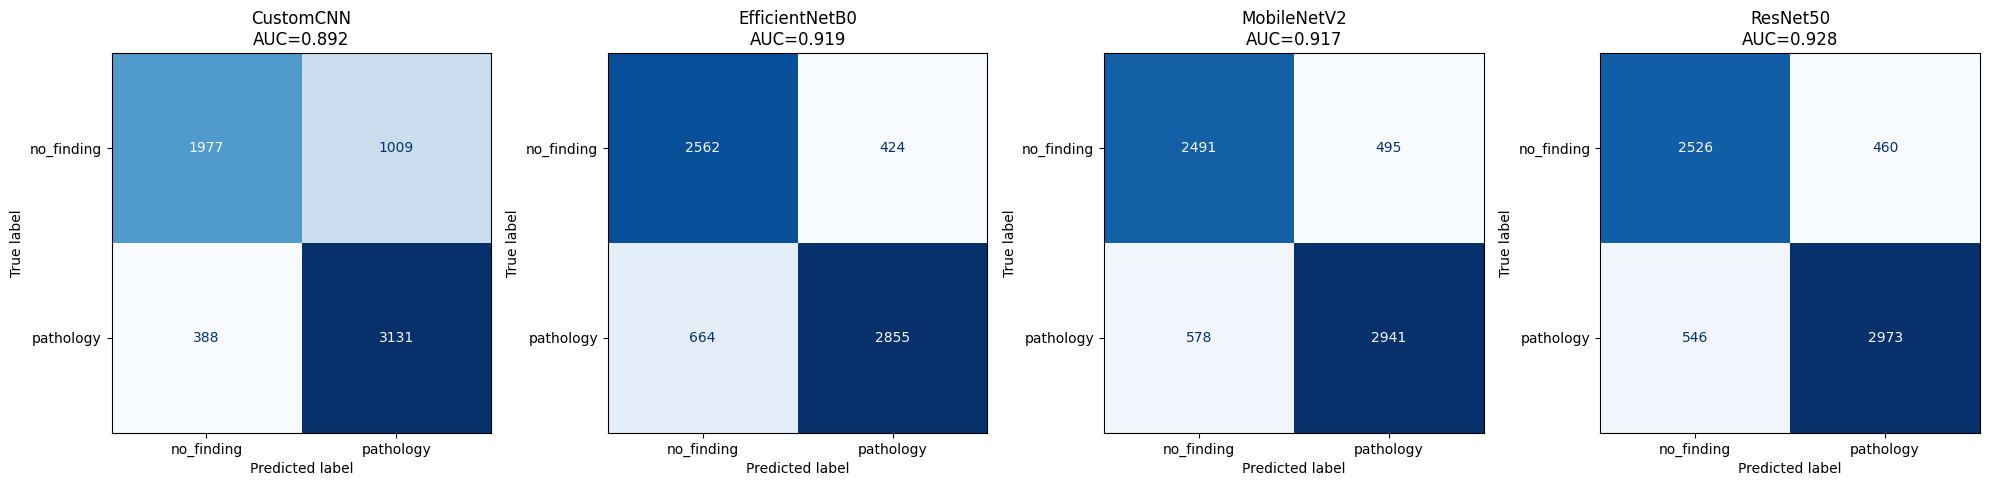

Saved chest_stage10_confusion.png


In [12]:
# ===== STAGE 10a: 4-PANEL CONFUSION MATRIX =====
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, row in zip(axes, summary_df.itertuples()):
    cm = np.array([[row.tn, row.fp], [row.fn, row.tp]])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=FINAL_CLASSES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{row.model}\nAUC={row.auc:.3f}")
plt.tight_layout()
plt.savefig('/kaggle/working/chest_stage10_confusion.png', dpi=150)
plt.show()
print("Saved chest_stage10_confusion.png")

In [13]:
# ===== STAGE 10b: SYSTEMATIC EXEMPLAR SELECTION (disagreement protocol) =====
test_df_reset = test_df.reset_index(drop=True)

custom_wrong = predictions['CustomCNN']['yhat'] != y_true
eff_right    = predictions['EfficientNetB0']['yhat'] == y_true
mob_right    = predictions['MobileNetV2']['yhat'] == y_true
res_right    = predictions['ResNet50']['yhat'] == y_true

disagreement_mask = custom_wrong & eff_right & mob_right & res_right
print(f"Total disagreement-protocol candidates: {disagreement_mask.sum()}")

pathology_candidates  = np.where(disagreement_mask & (y_true == 1))[0]
no_finding_candidates = np.where(disagreement_mask & (y_true == 0))[0]
print(f"Pathology candidates: {len(pathology_candidates)} | No-finding candidates: {len(no_finding_candidates)}")

assert len(pathology_candidates) > 0, "No pathology exemplar satisfies the disagreement protocol"
assert len(no_finding_candidates) > 0, "No no_finding exemplar satisfies the disagreement protocol"

# systematic pick: first candidate by index, not chosen by eye
exemplar_pathology_idx  = int(pathology_candidates[0])
exemplar_no_finding_idx = int(no_finding_candidates[0])

exemplar_pathology_path  = test_df_reset.loc[exemplar_pathology_idx, 'image_path']
exemplar_no_finding_path = test_df_reset.loc[exemplar_no_finding_idx, 'image_path']
exemplar_pathology_src   = test_df_reset.loc[exemplar_pathology_idx, 'source']
exemplar_no_finding_src  = test_df_reset.loc[exemplar_no_finding_idx, 'source']

print(f"\nPathology exemplar: idx={exemplar_pathology_idx} source={exemplar_pathology_src}")
print(f"  {exemplar_pathology_path}")
print(f"No-finding exemplar: idx={exemplar_no_finding_idx} source={exemplar_no_finding_src}")
print(f"  {exemplar_no_finding_path}")

Total disagreement-protocol candidates: 567
Pathology candidates: 66 | No-finding candidates: 501

Pathology exemplar: idx=2311 source=nih
  /kaggle/input/datasets/organizations/nih-chest-xrays/data/images_002/images/00001483_011.png
No-finding exemplar: idx=97 source=chex
  /kaggle/input/datasets/ashery/chexpert/train/patient02559/study1/view1_frontal.jpg


done: Pathology (nih) / CustomCNN
done: Pathology (nih) / EfficientNetB0
done: Pathology (nih) / MobileNetV2
done: Pathology (nih) / ResNet50
done: No_finding (chex) / CustomCNN
done: No_finding (chex) / EfficientNetB0
done: No_finding (chex) / MobileNetV2
done: No_finding (chex) / ResNet50


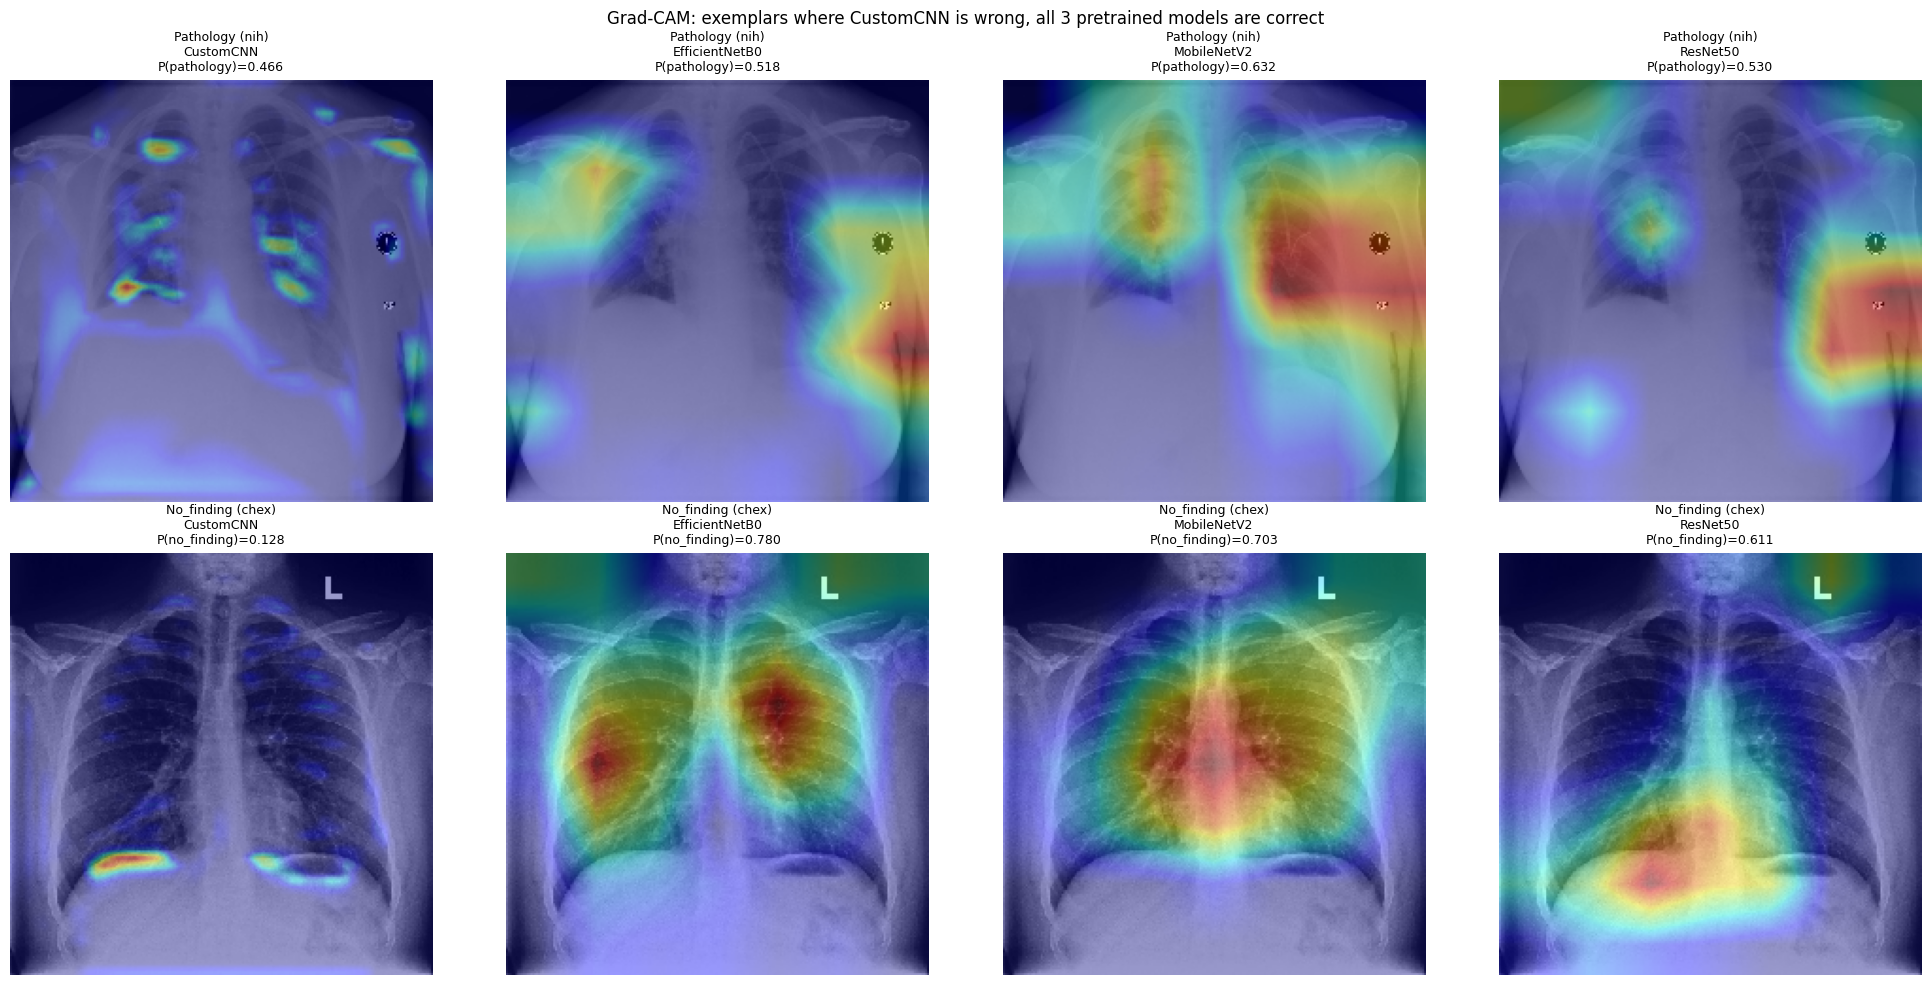

Saved chest_stage10_gradcam.png


In [15]:
# ===== STAGE 10c (fixed): GRAD-CAM ON CPU (determinism blocks fused BN backprop on GPU) =====
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as kimage
from tensorflow.keras.models import Model

def load_img_for_model(path, preprocess_fn):
    img = kimage.load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = kimage.img_to_array(img)
    display_arr = arr.astype('uint8')
    batch = np.expand_dims(arr, axis=0)
    batch = batch / 255.0 if preprocess_fn is None else preprocess_fn(batch)
    return batch, display_arr

def gradcam_pretrained(full_model, base, last_conv_name, img_batch, class_idx):
    dual_model = Model(inputs=base.input, outputs=[base.get_layer(last_conv_name).output, base.output])
    head_layers = full_model.layers[1:]
    img_tensor = tf.convert_to_tensor(img_batch)
    with tf.GradientTape() as tape:
        conv_out, base_out = dual_model(img_tensor)
        tape.watch(conv_out)
        x = base_out
        for layer in head_layers:
            x = layer(x)
        class_score = x[:, class_idx]
    grads = tape.gradient(class_score, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.squeeze(conv_out[0] @ pooled_grads[..., tf.newaxis])
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), float(x[0, class_idx])

def gradcam_custom(model, img_batch, class_idx):
    conv_idx = [i for i, l in enumerate(model.layers) if isinstance(l, Conv2D)][-1]
    img_tensor = tf.convert_to_tensor(img_batch)
    with tf.GradientTape() as tape:
        x = img_tensor
        conv_out = None
        for i, layer in enumerate(model.layers):
            x = layer(x)
            if i == conv_idx:
                conv_out = x
                tape.watch(conv_out)
        class_score = x[:, class_idx]
    grads = tape.gradient(class_score, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.squeeze(conv_out[0] @ pooled_grads[..., tf.newaxis])
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), float(x[0, class_idx])

def overlay_heatmap(display_img, heatmap, alpha=0.4):
    hm = tf.image.resize(heatmap[..., tf.newaxis], (IMG_SIZE, IMG_SIZE)).numpy().squeeze()
    coloured = plt.get_cmap('jet')(hm)[..., :3] * 255
    return (display_img.astype('float32') * (1 - alpha) + coloured * alpha).astype('uint8')

exemplars = [
    ('Pathology (nih)', exemplar_pathology_path, 1),
    ('No_finding (chex)', exemplar_no_finding_path, 0),
]
model_specs = {
    'CustomCNN':      (CHEST_WEIGHTS_DIR + 'best_custom_cnn_chest.keras', None, 'custom'),
    'EfficientNetB0': (CHEST_WEIGHTS_DIR + 'best_efficientnet_chest.keras', eff_pre, 'top_conv'),
    'MobileNetV2':    (CHEST_WEIGHTS_DIR + 'best_mobilenet_chest.keras', mob_pre, 'Conv_1'),
    'ResNet50':       (CHEST_WEIGHTS_DIR + 'best_resnet50_chest.keras', res_pre, 'conv5_block3_out'),
}

fig, axes = plt.subplots(len(exemplars), len(model_specs), figsize=(20, 10))

# CPU scope: determinism has no GPU kernel for fused BN backprop in inference mode.
# Visualisation only, does not affect any locked result.
with tf.device('/CPU:0'):
    for row_i, (ex_label, ex_path, class_idx) in enumerate(exemplars):
        for col_i, (name, (path, preproc, last_conv)) in enumerate(model_specs.items()):
            m = load_model(path)
            img_batch, display_arr = load_img_for_model(ex_path, preproc)
            if last_conv == 'custom':
                heatmap, score = gradcam_custom(m, img_batch, class_idx)
            else:
                heatmap, score = gradcam_pretrained(m, m.layers[0], last_conv, img_batch, class_idx)
            axes[row_i, col_i].imshow(overlay_heatmap(display_arr, heatmap))
            axes[row_i, col_i].set_title(f"{ex_label}\n{name}\nP({FINAL_CLASSES[class_idx]})={score:.3f}", fontsize=9)
            axes[row_i, col_i].axis('off')
            print(f"done: {ex_label} / {name}")
            del m
            import gc; gc.collect()

plt.suptitle('Grad-CAM: exemplars where CustomCNN is wrong, all 3 pretrained models are correct')
plt.tight_layout()
plt.savefig('/kaggle/working/chest_stage10_gradcam.png', dpi=150)
plt.show()
print("Saved chest_stage10_gradcam.png")

done: Pathology (nih) / CustomCNN | pred=no_finding wrong=True
done: Pathology (nih) / EfficientNetB0 | pred=pathology wrong=False
done: Pathology (nih) / MobileNetV2 | pred=pathology wrong=False
done: Pathology (nih) / ResNet50 | pred=pathology wrong=False
done: No_finding (chex) / CustomCNN | pred=pathology wrong=True
done: No_finding (chex) / EfficientNetB0 | pred=no_finding wrong=False
done: No_finding (chex) / MobileNetV2 | pred=no_finding wrong=False
done: No_finding (chex) / ResNet50 | pred=no_finding wrong=False


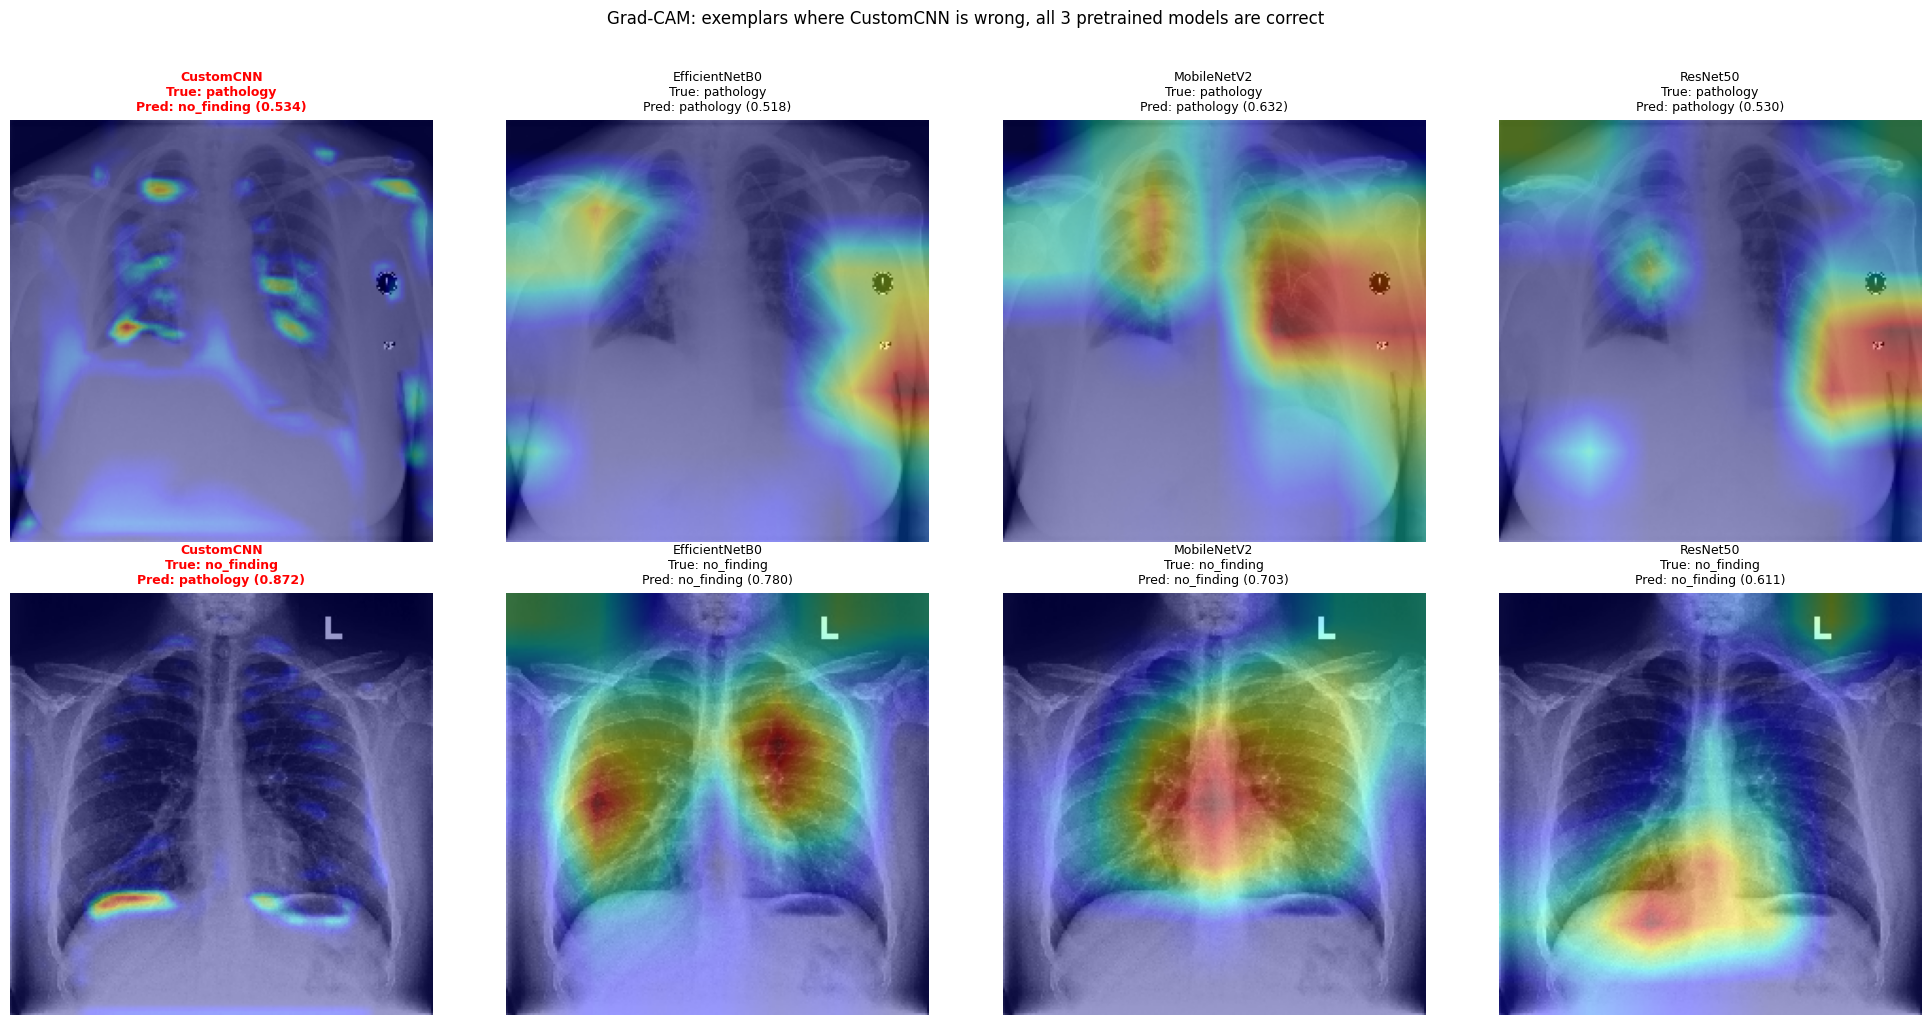

Saved chest_stage10_gradcam.png


In [16]:
# ===== STAGE 10c (v2): GRAD-CAM WITH PRED LABEL + RED HIGHLIGHT WHEN WRONG =====
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as kimage
from tensorflow.keras.models import Model

def load_img_for_model(path, preprocess_fn):
    img = kimage.load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = kimage.img_to_array(img)
    display_arr = arr.astype('uint8')
    batch = np.expand_dims(arr, axis=0)
    batch = batch / 255.0 if preprocess_fn is None else preprocess_fn(batch)
    return batch, display_arr

def gradcam_pretrained(full_model, base, last_conv_name, img_batch, class_idx):
    dual_model = Model(inputs=base.input, outputs=[base.get_layer(last_conv_name).output, base.output])
    head_layers = full_model.layers[1:]
    img_tensor = tf.convert_to_tensor(img_batch)
    with tf.GradientTape() as tape:
        conv_out, base_out = dual_model(img_tensor)
        tape.watch(conv_out)
        x = base_out
        for layer in head_layers:
            x = layer(x)
        class_score = x[:, class_idx]
    grads = tape.gradient(class_score, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.squeeze(conv_out[0] @ pooled_grads[..., tf.newaxis])
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    full_probs = x[0].numpy()
    return heatmap.numpy(), full_probs

def gradcam_custom(model, img_batch, class_idx):
    conv_idx = [i for i, l in enumerate(model.layers) if isinstance(l, Conv2D)][-1]
    img_tensor = tf.convert_to_tensor(img_batch)
    with tf.GradientTape() as tape:
        x = img_tensor
        conv_out = None
        for i, layer in enumerate(model.layers):
            x = layer(x)
            if i == conv_idx:
                conv_out = x
                tape.watch(conv_out)
        class_score = x[:, class_idx]
    grads = tape.gradient(class_score, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.squeeze(conv_out[0] @ pooled_grads[..., tf.newaxis])
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    full_probs = x[0].numpy()
    return heatmap.numpy(), full_probs

def overlay_heatmap(display_img, heatmap, alpha=0.4):
    hm = tf.image.resize(heatmap[..., tf.newaxis], (IMG_SIZE, IMG_SIZE)).numpy().squeeze()
    coloured = plt.get_cmap('jet')(hm)[..., :3] * 255
    return (display_img.astype('float32') * (1 - alpha) + coloured * alpha).astype('uint8')

exemplars = [
    ('Pathology (nih)', exemplar_pathology_path, 1),
    ('No_finding (chex)', exemplar_no_finding_path, 0),
]
model_specs = {
    'CustomCNN':      (CHEST_WEIGHTS_DIR + 'best_custom_cnn_chest.keras', None, 'custom'),
    'EfficientNetB0': (CHEST_WEIGHTS_DIR + 'best_efficientnet_chest.keras', eff_pre, 'top_conv'),
    'MobileNetV2':    (CHEST_WEIGHTS_DIR + 'best_mobilenet_chest.keras', mob_pre, 'Conv_1'),
    'ResNet50':       (CHEST_WEIGHTS_DIR + 'best_resnet50_chest.keras', res_pre, 'conv5_block3_out'),
}

fig, axes = plt.subplots(len(exemplars), len(model_specs), figsize=(20, 10))

with tf.device('/CPU:0'):
    for row_i, (ex_label, ex_path, true_idx) in enumerate(exemplars):
        for col_i, (name, (path, preproc, last_conv)) in enumerate(model_specs.items()):
            m = load_model(path)
            img_batch, display_arr = load_img_for_model(ex_path, preproc)
            if last_conv == 'custom':
                heatmap, full_probs = gradcam_custom(m, img_batch, true_idx)
            else:
                heatmap, full_probs = gradcam_pretrained(m, m.layers[0], last_conv, img_batch, true_idx)

            pred_idx = int(np.argmax(full_probs))
            pred_label = FINAL_CLASSES[pred_idx]
            true_label = FINAL_CLASSES[true_idx]
            is_wrong = pred_idx != true_idx

            ax = axes[row_i, col_i]
            ax.imshow(overlay_heatmap(display_arr, heatmap))
            title_colour = 'red' if is_wrong else 'black'
            ax.set_title(f"{name}\nTrue: {true_label}\nPred: {pred_label} ({full_probs[pred_idx]:.3f})",
                         fontsize=9, color=title_colour, fontweight='bold' if is_wrong else 'normal')
            ax.axis('off')
            print(f"done: {ex_label} / {name} | pred={pred_label} wrong={is_wrong}")
            del m
            import gc; gc.collect()

plt.suptitle('Grad-CAM: exemplars where CustomCNN is wrong, all 3 pretrained models are correct', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/chest_stage10_gradcam.png', dpi=150)
plt.show()
print("Saved chest_stage10_gradcam.png")